 

*Facial Emotion Detection*

 

### **Description & Problem Definition**

 

The project investigates the effectiveness of custom convolutional
neural networks versus pretrained transfer learning models for
multi-class facial emotion classification. The dataset contains four
emotional categories: happy, sad, neutral, and surprise. The custom CNN
architectures were progressively scaled and regularized to examine the
impact on feature extraction. This was compared to the pretrained frozen
models: VGG16, ResNet50V2, and EfficientNetB0. The workflow included
data preprocessing, exploratory visualization, model development,
training, and evaluation. Data augmentation and normalization were
applied to improve generalization, and models were compared using
validation accuracy and loss to select the best-performing model.  
  
As people increasingly rely on computers for virtual meetings, online
communication, and remote work, facial emotion detection becomes more
important. In face-to-face interactions, we rely on facial expressions
to understand mood, attention, confusion, agreement, discomfort, or
emotional response. However, in virtual environments, these cues can be
harder to interpret.  
  
Facial emotion detection can help computer systems and people understand
emotional cues during digital interactions. This could support
emotion-focused technological development. Because virtual communication
is becoming more common, developing accurate models that can classify
facial expressions is an important problem.  
  
This project addresses whether deep learning models can accurately
classify facial expressions into four categories: happy, neutral, sad,
and surprise. This project uses labeled facial images to train and
evaluate convolutional neural network models and transfer learning
models. The objective is to build a deep learning model that can
accurately detect facial emotions through multi-class image
classification. The goal is to determine which model performs best and
whether custom grayscale CNNs can outperform frozen pretrained RGB
transfer learning models on the dataset.

 

### **Mounting the Drive**

 

**Reasoning:** This helps to ensure file access and to precent path
failures later.

In \[ \]:

    from google.colab import drive # Imports Google Colab drive module
    drive.mount('/content/drive') # Mounts Google Drive

Mounted at /content/drive

 

**Interpretation:**  
Mounting the Google Drive for direct access to needed file.

 

### **Importing the Libraries**

 

**Reasoning:** Creates the technical enviroment for the workflow and
makes the notebook self-contained.

In \[ \]:

    import os # Operating system interface for Python. Allows interacting with files and directories
    import zipfile # Allows extracting or compressing datasets
    import random # Helps randomizing for sampling
    from pathlib import Path # Allows managing file paths
    import numpy as np # Computin library that handles arrays and matrix operations
    import pandas as pd # Works with structured data to allow analysis
    import matplotlib.pyplot as plt # Allows creating graphs and charts
    import seaborn as sns # enhanced statistical visualization
    from PIL import Image # Allows for editing and processing images

    import tensorflow as tf # Deep learning framework that allows training, GPU computation and the handling of tensors
    from tensorflow.keras.callbacks import ReduceLROnPlateau
    from tensorflow.keras.preprocessing.image import ImageDataGenerator # Loads images from folders and allows for transformations
    from tensorflow.keras.models import Sequential, Model # Allows for transfer learning and mult input/output models
    from tensorflow.keras.layers import ( # Includes several functions
        Input, Conv2D, MaxPooling2D, Flatten, Dense, # Allowing for defining shape, learning patterns and boundaries, filtering of strong features, conversion, decisions,
        Dropout, BatchNormalization, GlobalAveragePooling2D # Overfitting protections, normalization and safeguards
    )

    from tensorflow.keras.optimizers import Adam # Updates weights during training
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Prevents overfitting by stopping training when improvement stops
    from tensorflow.keras.applications import VGG16, ResNet50V2, EfficientNetB0 # Pretrained architectures trained on ImageNet
    from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess # Prepares images for VGG16
    from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess # Prepares images for ResNet
    from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess # Prepares images for EfficientNet
    from sklearn.metrics import confusion_matrix, classification_report # Shows true versus predicted classes, identifies bias and misclassification patterns

 

**Interpretation:** Importing tools needed for file handling, plotting,
image processing, CNN training, transfer learning, and classification
diagnostics.

 

**Reasoning:** Deep learning containse some stochastic behavior and this
step helps to improve reproducibility.

In \[ \]:

    SEED = 42 # Starting point for randomness
    os.environ["PYTHONHASHSEED"] = str(SEED) # Forces hashing to be deterministic
    random.seed(SEED) # Ensures same random choices every run
    np.random.seed(SEED) # Controls NumPy randomness
    tf.random.set_seed(SEED) # Controls TensorFlow randomness

 

**Interpretation:** Improves reproducibility by reducing randomness.
This helps to make runs more stable.

 

### **Loading and unzipping the data**

 

**Reasoning:** This helps to ensure a clean dataset state and avoid
contimination from earlier runs.

In \[ \]:

    import shutil # Added for rmtree function
    zip_path = "/content/drive/MyDrive/Facial_emotion_images (3).zip" # Tells Python where in your drive to find the data
    extract_path = "/content/facial_emotion_data" # Destination of extracted data

    if os.path.exists(extract_path): # Checks if extracted folder already exists
        print("Cleaning existing extracted folder...") # Informs of cleanup
        shutil.rmtree(extract_path) # Prevents duplicates by deleting folder and contents

    os.makedirs(extract_path, exist_ok=True) # Prevents crashing if folder already exists and creates a safe directory

    with zipfile.ZipFile(zip_path, "r") as zip_ref: # Opens zip file in read mode
        zip_ref.extractall(extract_path) # Extracts all files in target directory

    print("Dataset extracted successfully.") # Confirmation message
    print("Top-level contents:", os.listdir(extract_path)) # Lists files and folders inside extraction directory

    def find_dataset_root(base_path): # Finds the dataset home location

        for root, dirs, files in os.walk(base_path): # Goes through all folders indefinitely and returns the current directory, subfolders and files
            if {"train", "validation", "test"}.issubset(set(dirs)): # Checks if the folder contains the train, validation and test subfolders
                return root # Returns correct dataset root folder
        return None # If none is found it returns none

    dataset_root = find_dataset_root(extract_path) # Stores the result in dataset_root

    if dataset_root is None: # Checks if dataset structure was found
        raise FileNotFoundError("Could not find dataset root with train/validation/test folders.") # Stops execution if the structure is wrong

    train_dir = os.path.join(dataset_root, "train") # Path to training images
    val_dir = os.path.join(dataset_root, "validation") # Path to validation images
    test_dir = os.path.join(dataset_root, "test") # Path to test images

    print("Train folder:", train_dir) # Confirms path and verifies structure
    print("Validation folder:", val_dir) # Confirms path and verifies structure
    print("Test folder:", test_dir) # Confirms path and verifies structure

Dataset extracted successfully. Top-level contents:
\['Facial_emotion_images'\] Train folder:
/content/facial_emotion_data/Facial_emotion_images/train Validation
folder: /content/facial_emotion_data/Facial_emotion_images/validation
Test folder: /content/facial_emotion_data/Facial_emotion_images/test

 

**Interpretation:** The image dataset was succesfully extraced from the
zip file and loaded into the Colab runtime.

 

**Reasoning:** Dataset issues often look like bad model performance.
This helps to reveal the issue and shows class imbalance in
train/validation and a balanced test set.

In \[ \]:

    expected_classes = ["happy", "neutral", "sad", "surprise"] # List of classes

    for split_name, split_dir in [ # Iterates through dataset partitions and avoids repeating code
        ("Train", train_dir), # Iterates through training directory
        ("Validation", val_dir), # Iterates through validation directory
        ("Test", test_dir) # Iterates through testing directory
    ]:
        print(f"\nChecking {split_name} folder") # Printing split header and sperating output of each dataset split clearly
        found_classes = sorted(os.listdir(split_dir)) # Detecting available claasses and listing all folders
        print("Classes found:", found_classes) # Displays detected class folders

        for cls in expected_classes: # Iterates through expected class list and checks for what should exist
            class_path = os.path.join(split_dir, cls) # Constructs path and ensures safe path handling
            image_count = len(os.listdir(class_path)) # Counts the number of files in each class folder
            print(f"{cls}: {image_count} images") # Displays class distribution

Checking Train folder Classes found: \['happy', 'neutral', 'sad',
'surprise'\] happy: 3976 images neutral: 3978 images sad: 3982 images
surprise: 3173 images Checking Validation folder Classes found:
\['happy', 'neutral', 'sad', 'surprise'\] happy: 1825 images neutral:
1216 images sad: 1139 images surprise: 797 images Checking Test folder
Classes found: \['happy', 'neutral', 'sad', 'surprise'\] happy: 32
images neutral: 32 images sad: 32 images surprise: 32 images

 

**Interpretation:** Checking whether all expected emotion classes exist
in each split and the image counts. All four classes are contained in
all three splits. Train: happy 3976, sad 3982, suprise 3173, neutral
3978, 15,109 total. Validation: happy 1825, sad 1139, suprise 797,
neutral 1216, 4,977 total. Test 32 images per class, 128 total. There is
balance in the happy, sad, and neutral classes. Suprise is imbalanced.

 

### **Visualizing Classes**

  

 

**Reasoning:** This serves as a visual check on image quality and class
appearance. It helps to show if a class contains abnormalities.

In \[ \]:

    def show_class_samples(data_dir, class_name, n=5): # Allows for quickly inspecting classes in a split
        class_path = os.path.join(data_dir, class_name) # Ensures safe path handling
        image_names = random.sample(os.listdir(class_path), n) # Picks a number of random images and prevents duplicates

        plt.figure(figsize=(15, 3)) # Creates plotting canvas
        for i, image_name in enumerate(image_names, 1): # Loops through selected images
            img_path = os.path.join(class_path, image_name) # Full file path to image
            img = plt.imread(img_path) # Reads image into NumPy array

            plt.subplot(1, n, i) # Creates a subplot
            if len(img.shape) == 2: # Checks if image is grayscale
                plt.imshow(img, cmap="gray") # Displays grayscale image
            else:
                plt.imshow(img) # Displays RGB image
            plt.title(class_name.capitalize()) # Labels each image
            plt.axis("off") # cleans visualization by removing ticks and borders

        plt.tight_layout() # Prevents overlapping between images and titles
        plt.show() # Displays images

    for emotion in ["happy", "neutral", "sad", "surprise"]: # Loops through all emotion classes
        show_class_samples(train_dir, emotion, n=5) # Displays 5 random images for each class from the training sets

<img
src="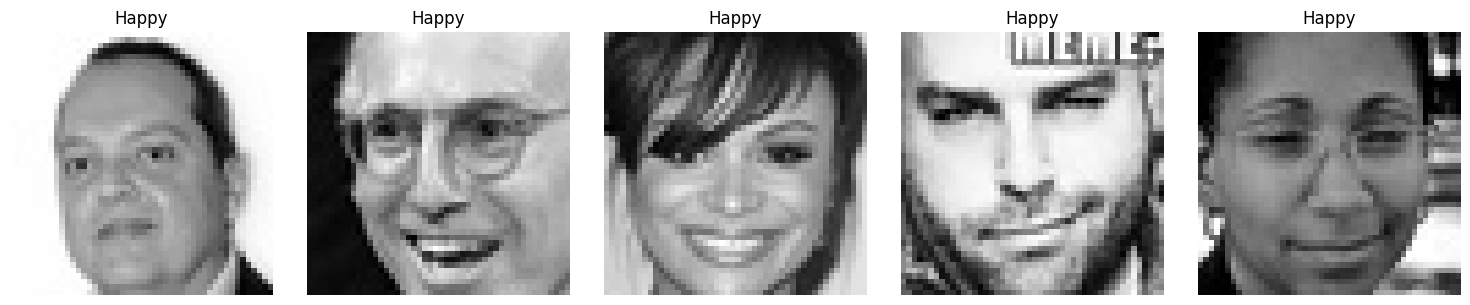%0A"
class="output-image" alt="Output" />

<img
src="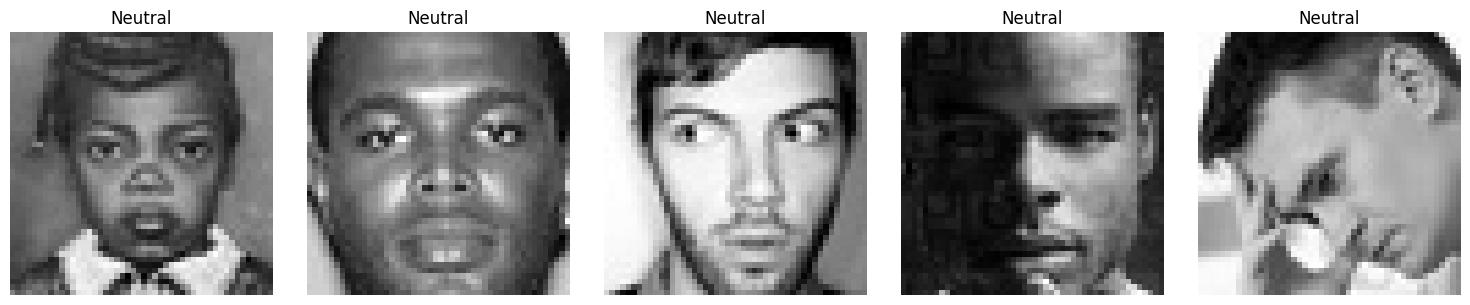%0A"
class="output-image" alt="Output" />

<img
src="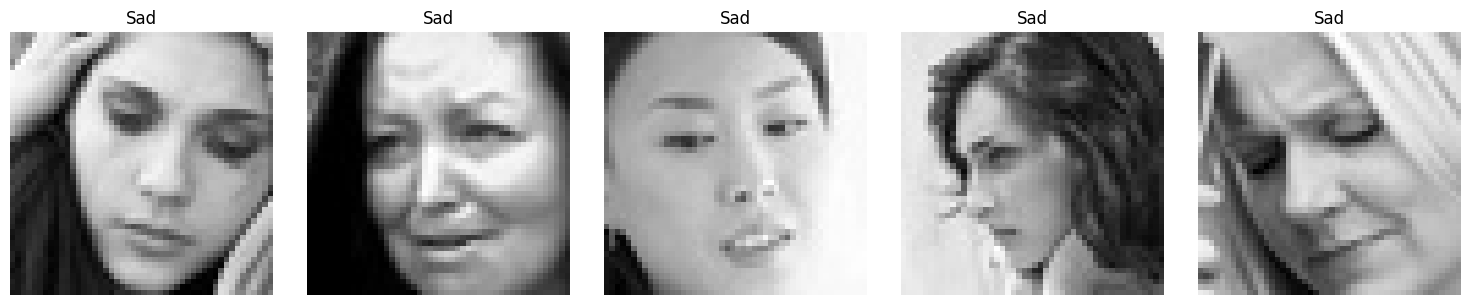%0A"
class="output-image" alt="Output" />

<img
src="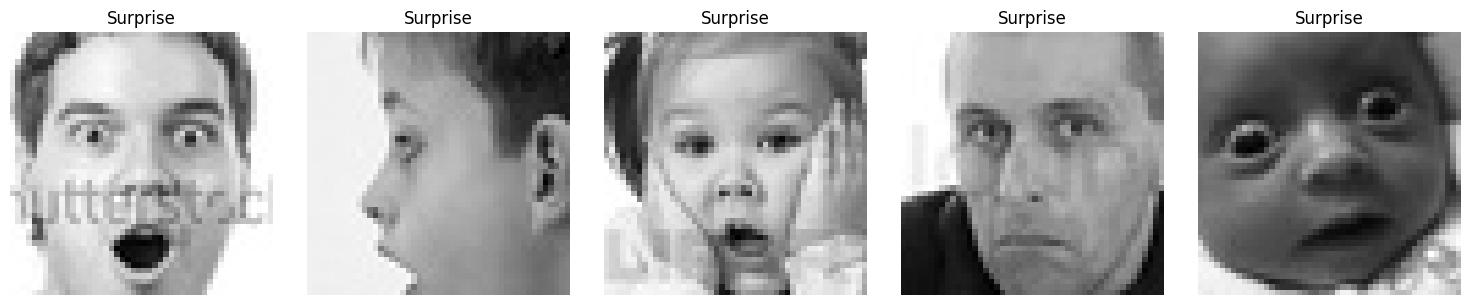%0A"
class="output-image" alt="Output" />

 

**Interpretation:** Low resolution images are randomly displayed for
each class. The images are read and displayed correctly. This shows the
variability in expression.

 

### **Happy**

 

**Reasoning:** Serves as a visual aid to understand what cues the model
relies on for classifying happy.

In \[ \]:

    happy_path = os.path.join(train_dir, "happy") # Creates a path to happy images in training set
    happy_images = random.sample(os.listdir(happy_path), 5) # Lists all files in folder and randomly selects 5 images
    plt.figure(figsize=(15, 3)) # Creates plot canvas

    for i, img_name in enumerate(happy_images, 1): # Iterates through selected images

        img_path = os.path.join(happy_path, img_name) # Creates path to each image file
        img = plt.imread(img_path) # Loads images into memory
        plt.subplot(1, 5, i) # Creating subplot

        if len(img.shape) == 2: # Checking if image is grayscale
            plt.imshow(img, cmap="gray") # Displays grayscale correctly
        else:
            plt.imshow(img) # Displays RGB images normally

        plt.title("happy") # Labels each image as happy
        plt.axis("off") # Removes ticks and borders

    plt.tight_layout() # Prevents overlapping images and titles
    plt.show() # Displaying plot

<img
src="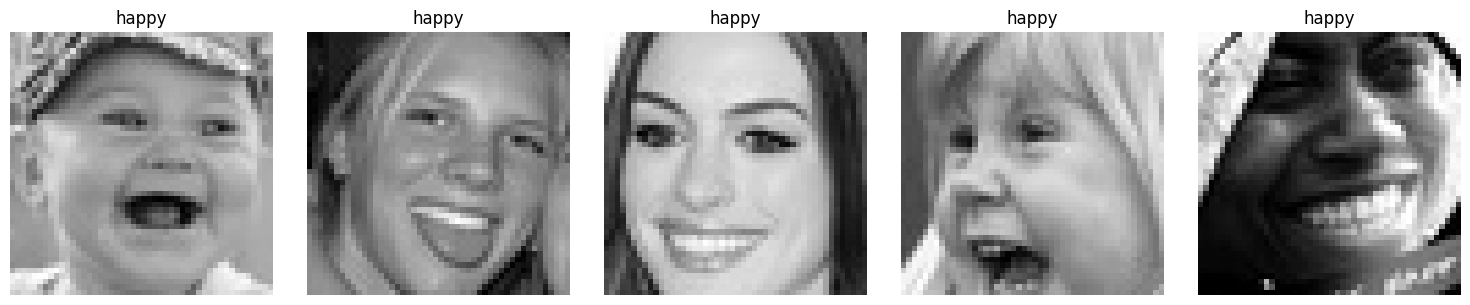%0A"
class="output-image" alt="Output" />

 

**Interpretation:** Five happy class images are displayed. This confirms
the class folder structure and reading are working correctly.

 

### **Sad**

 

**Reasoning:** Serves as a visual aid to understand what cues the model
relies on for classifying sad.

In \[ \]:

    sad_path = os.path.join(train_dir, "sad") # Creates path to sad class folder
    sad_images = random.sample(os.listdir(sad_path), 5) # Randomly selects 5 images from the sad folder
    plt.figure(figsize=(15, 3)) # Creating figure

    for i, img_name in enumerate(sad_images, 1): # Iterates through selected images
        img_path = os.path.join(sad_path, img_name) # Path to each image
        img = plt.imread(img_path) # Loads image
        plt.subplot(1, 5, i) # Creates subplot

        if len(img.shape) == 2: # Ensures grayscale images display correctly
            plt.imshow(img, cmap="gray") # Display grayscale images
        else:
            plt.imshow(img) # Displays color images

        plt.title("Sad") # Labels each image
        plt.axis("off") # Cleaner visualization by removing ticks and borders

    plt.tight_layout() # Prevents overlapping images and titles
    plt.show() # Displays plot

<img
src="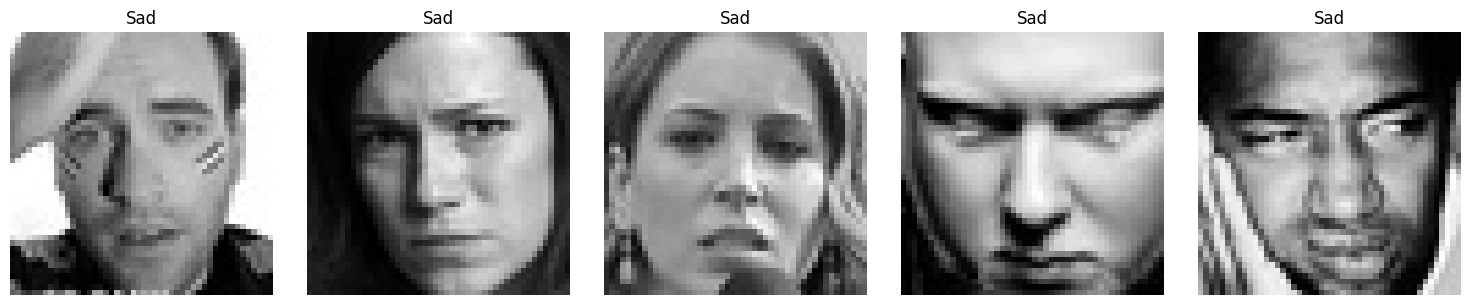%0A"
class="output-image" alt="Output" />

 

**Interpretation:** Five happy class images are displayed. This confirms
the class folder structure and reading are working correctly.

 

### **Neutral**

 

**Reasoning:** Serves as a visual aid to understand what cues the model
relies on for classifying neutral.

In \[ \]:

    neutral_path = os.path.join(train_dir, "neutral") # Creates path to neutral class folder
    neutral_images = random.sample(os.listdir(neutral_path), 5) # Randomly selects 5 images from the neutral folder
    plt.figure(figsize=(15, 3)) # Creating figure

    for i, img_name in enumerate(neutral_images, 1): # Iterates through selected images
        img_path = os.path.join(neutral_path, img_name) # Creates path to each image
        img = plt.imread(img_path) # Loads plot
        plt.subplot(1, 5, i) # Creates subplot

        if len(img.shape) == 2: # Ensures grayscale images display correctly
            plt.imshow(img, cmap="gray")  # Display grayscale images
        else:
            plt.imshow(img)  # Display RGB images

        plt.title("Neutral") # Labels each image
        plt.axis("off") # Cleaner visualization by removing ticks and borders

    plt.tight_layout() # Prevents overlapping images and titles
    plt.show() # Displays plot

<img
src="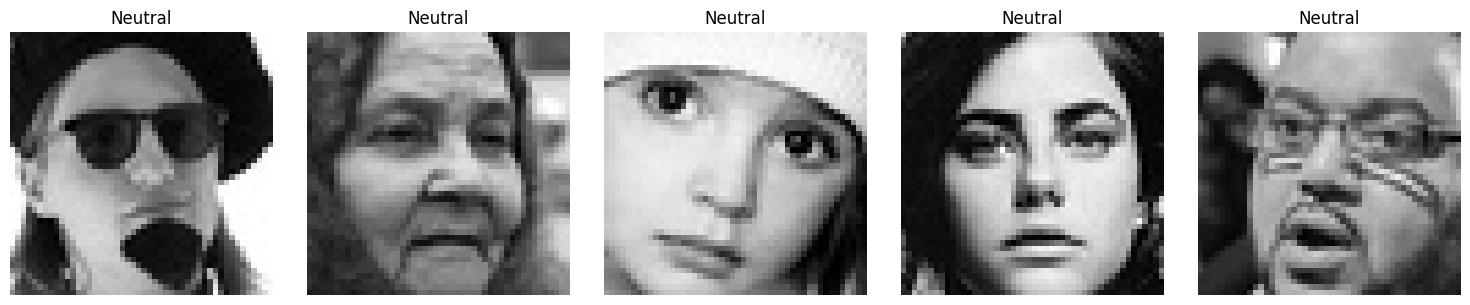%0A"
class="output-image" alt="Output" />

 

**Interpretation:** Five happy class images are displayed. This confirms
the class folder structure and reading are working correctly.

 

### **Surprised**

 

**Reasoning:** Serves as a visual aid to understand what cues the model
relies on for classifying suprised.

In \[ \]:

    surprise_path = os.path.join(train_dir, "surprise") # Creates path to suprised class folder
    surprise_images = random.sample(os.listdir(surprise_path), 5) # Randomly selects 5 images from the suprised folder
    plt.figure(figsize=(15, 3)) # Creating figure

    for i, img_name in enumerate(surprise_images, 1): # Iterates through selected images
        img_path = os.path.join(surprise_path, img_name) # Path to each image
        img = plt.imread(img_path) # Loads plot
        plt.subplot(1, 5, i) # Creates subplot

        if len(img.shape) == 2: # Ensures grayscale images display correctly
            plt.imshow(img, cmap="gray")  # Display grayscale images
        else:
            plt.imshow(img)  # Display RGB images

        plt.title("Surprised") # Labels each image
        plt.axis("off") # Cleaner visualization by removing ticks and borders

    plt.tight_layout() # Prevents overlapping images and titles
    plt.show() # Displays plot

<img
src="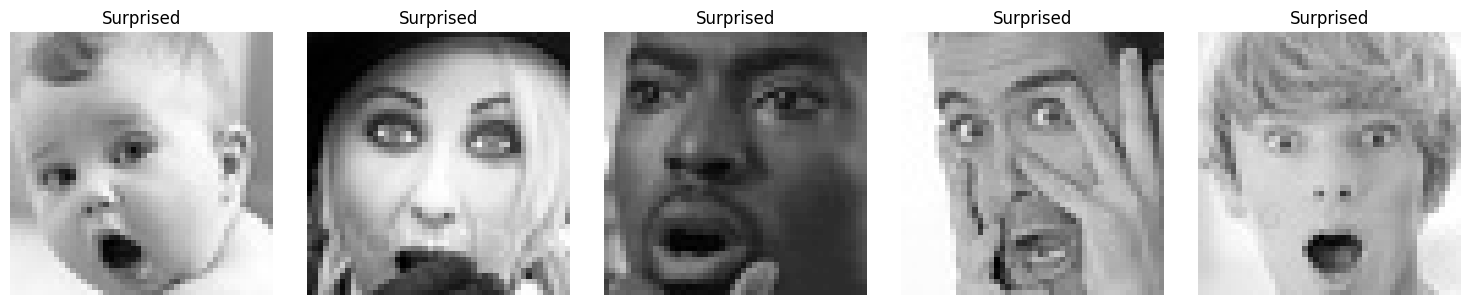%0A"
class="output-image" alt="Output" />

 

**Interpretation:** Five happy class images are displayed. This confirms
the class folder structure and reading are working correctly.

 

### **Checking Distribution of Classes**

 

**Reasoning:** Turns class counts into a structured DataFrame so
distribution can analyzed. It makes the characteristics easier to
communicate and defend.

In \[ \]:

    def get_class_counts(data_dir, split_name): # Counts how many images exist per class in a dataset split
        counts = {} # Creates empty dictionary
        for class_name in sorted(os.listdir(data_dir)): # Lists and sorts all items in a directory
            class_path = os.path.join(data_dir, class_name) # Constructs path to each class folder

            if os.path.isdir(class_path): # Prevents errors from stray files
                counts[class_name] = len(os.listdir(class_path)) # Counts number of files in each class folder and stores in dictionary

        df = pd.DataFrame({ # Converts dictionary to a structured table
            "Class": list(counts.keys()), # Class
            "Count": list(counts.values()), # Counts
            "Split": split_name # Split name
        })

        return df # Returns counts after split

    train_counts = get_class_counts(train_dir, "Train") # Counts training data
    val_counts = get_class_counts(val_dir, "Validation") # Counts validation data
    test_counts = get_class_counts(test_dir, "Test") # Counts test data
    class_counts_df = pd.concat([train_counts, val_counts, test_counts], ignore_index=True) # Combines all splits into one
    display(class_counts_df) # Shows DataFrame

|     | Class    | Count | Split      |
|-----|----------|-------|------------|
| 0   | happy    | 3976  | Train      |
| 1   | neutral  | 3978  | Train      |
| 2   | sad      | 3982  | Train      |
| 3   | surprise | 3173  | Train      |
| 4   | happy    | 1825  | Validation |
| 5   | neutral  | 1216  | Validation |
| 6   | sad      | 1139  | Validation |
| 7   | surprise | 797   | Validation |
| 8   | happy    | 32    | Test       |
| 9   | neutral  | 32    | Test       |
| 10  | sad      | 32    | Test       |
| 11  | surprise | 32    | Test       |





 

**Interpretation:** The count table successfully printed showing a good
structural check before training. This shows the number of images for
each split/class combination.

 

**Reasoning:** Impalance affects how accuracy, recall and F1 scores are
interpreted. The chart makes class imbalance more obvious.

In \[ \]:

    plt.figure(figsize=(10, 6)) # Creates plot canvas
    sns.barplot(data=class_counts_df, x="Class", y="Count", hue="Split") # Creates Bar plot
    plt.title("Distribution of Classes Across Train, Validation, and Test Sets") # Creates title

    plt.xlabel("Emotion Class") # Labels the x axis to emotion class
    plt.ylabel("Number of Images") # Labels the y axis to number of images
    plt.show() # Displays plot

<img
src="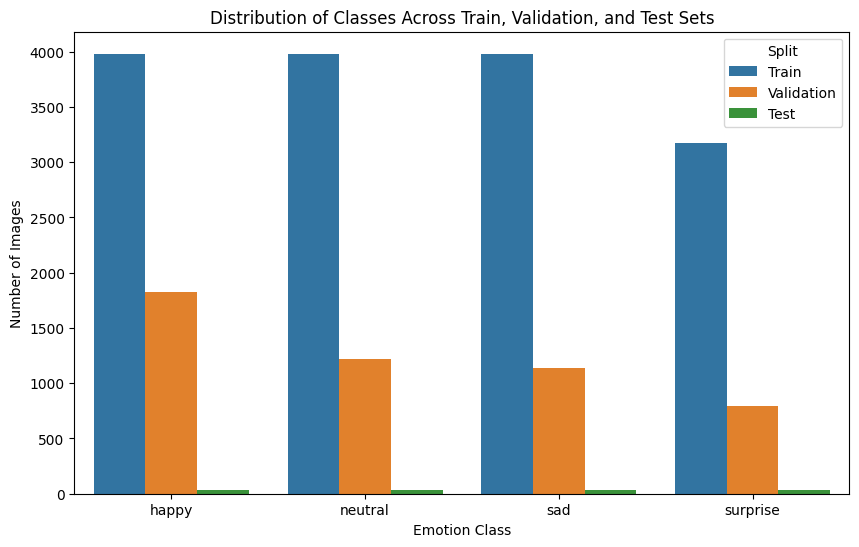%0A"
class="output-image" alt="Output" />

 

**Interpretation:** The grouped bar chart shows class counts and the
imbalance in validation. The suprise class showing the least images in
comparison to the other classes.

 

### **Helper Function**

 

**Reasoning:** Consistency across models makes the comparison fair. This
serves as the utility backbone ensuring consistency accross models.

In \[ \]:

    def plot_history(history, title): # Visualize how models learn over time
        plt.figure(figsize=(12, 4)) # Creates a figure with two plots side by side

        plt.subplot(1, 2, 1) # Grid layout 1 row, 2 columns and position 1 for the accuracy plot
        plt.plot(history.history["accuracy"], label="Train Accuracy")  # Plots training accuracy per epoch
        plt.plot(history.history["val_accuracy"], label="Validation Accuracy") # Plots validation accuracy per epoch
        plt.title(f"{title} - Accuracy") # Creates a title
        plt.xlabel("Epoch") # Labels the x axis Epoch
        plt.ylabel("Accuracy") # Labels the y axis Accuracy
        plt.legend() # Creates legend

        plt.subplot(1, 2, 2) # Creates second subplot, 1 row, 2 columns, and position 2 for loss
        plt.plot(history.history["loss"], label="Train Loss") # Plots training loss
        plt.plot(history.history["val_loss"], label="Validation Loss") # Plots validation loss
        plt.title(f"{title} - Loss") # Creates title
        plt.xlabel("Epoch") # Labels x axis Epoch
        plt.ylabel("Loss") # Labels y axis Loss
        plt.legend() # Creates legend

        plt.tight_layout() # Fixes spacing to prevent overlapping
        plt.show() # Displays plot


    def evaluate_model(model, generator, model_name): # Sets model, generator, and model_name parameters to be resused with different models
        loss, acc = model.evaluate(generator, verbose=1) # Runs model on the generator, computes loss and accuracy, and stores them
        print(f"{model_name} Loss: {loss:.4f}") # Displays output of loss
        print(f"{model_name} Accuracy: {acc:.4f}") # Displays output of accuracy
        return loss, acc # Prints and then returns variables to be used later


    def classification_diagnostics(model, generator, model_name): # # Sets model, generator, and model_name parameters to be used for error analysis
        generator.reset() # Resets the generator back to the beginning so it keeps its current position
        pred_probs = model.predict(generator, verbose=1) # Runs the model on all samples and returns predicted probabilities for each class
        pred_classes = np.argmax(pred_probs, axis=1) # Converts probability vectors into final indices

        true_classes = generator.classes # Stores ground truth labels in true classes
        class_labels = list(generator.class_indices.keys()) # Mapping class names to numeric IDs

        cm = confusion_matrix(true_classes, pred_classes) # Shows how oftern each true class was predicted as each class

        plt.figure(figsize=(6, 5)) # Creates figure for the confusion matrix
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", # Makes the confusion matrix readable
                    xticklabels=class_labels, yticklabels=class_labels) # Sets the x and y axis
        plt.title(f"{model_name} - Confusion Matrix") # Creates title
        plt.xlabel("Predicted") # Sets Predicted on the x axis
        plt.ylabel("True") # Sets True as the y axis
        plt.show() # Displays figure

        print(f"{model_name} Classification Report:\n") # Prints the heading above the report
        print(classification_report(true_classes, pred_classes, target_names=class_labels)) # Generates text summary of model performance and shows class names

    def make_callbacks(): # Creates and returns a list of callbacks
        early_stop = EarlyStopping( # Stops training when validation performance stops improving
            monitor="val_loss", # Monitors for validation loss
            patience=6, # Waits 6 epochs after last meaningful improvement before stopping.
            min_delta=0.0005, # If model improves less than 0.0005 it is treated as not meaningful
            restore_best_weights=True, # Restores last meaningful model weights
            verbose=1 # Prints message when early stopping is activated
        )

        reduce_lr = ReduceLROnPlateau( # Lowers the learning rate when improvement slows down
            monitor="val_loss", # Watches for validation loss
            factor=0.5, # When triggered the learning rate is multiplied by 0.5
            patience=2, # Waits 2 epochs without meaningful improvement before reducing learning rate
            min_delta=0.0005, # Only counts as improvement if  validation loss decreases by at least 0.0005
            min_lr=1e-6, # Sets smallest learning rate allowed
            verbose=1 # Prints messages when learning rate gets reduced
        )

        return [early_stop, reduce_lr] # Returns callback objects in a list

 

**Interpretation:** A utility function block that makes later modeling
sections cleaner and more reproducible. It standardizes training,
evaluating, confusion matrix and classification report generation,
callbacks, learning rate and early stopping.

 

### **Greyscale generator**

 

**Reasoning:** The custom models depend on a 48x48 grayscale input. This
builds the grayscale input pipeline for the custon CNNs.

In \[ \]:

    IMG_HEIGHT = 48 # Sets image height
    IMG_WIDTH = 48 # Sets image width
    BATCH_SIZE = 32 # Sets batch size

    train_datagen_gray = ImageDataGenerator( # Scales the pixels
        rescale=1.0/255, # Sets the parameter for scaling
        rotation_range=10, # Randomly rotates images up to 10 degrees
        width_shift_range=0.1, # Shifts images horizontally by up to 10%
        height_shift_range=0.1, # Shifts images vertically by up to 10%
        zoom_range=0.1, # Random zoom in/out
        horizontal_flip=True # Randomly flips images left-right
    )

    val_datagen_gray = ImageDataGenerator(rescale=1.0/255) # Validation generator only scales pixel values
    test_datagen_gray = ImageDataGenerator(rescale=1.0/255) # Train generator only scales pixel values

    train_gen_gray = train_datagen_gray.flow_from_directory( # Creates generator that loads images, applies augmentation, and feeds batches to the model
        train_dir, # Directory structure
        target_size=(IMG_HEIGHT, IMG_WIDTH), # Resizes every image to 48x48
        color_mode="grayscale", # Converts image to 1 channel
        batch_size=BATCH_SIZE, # Loads 32 images per batch
        class_mode="categorical", # Uses one-hot encoding for labels
        shuffle=True, # Randomizes order of images each epoch
        seed=SEED # Ensures reproducibility of shuffling
    )

    val_gen_gray = val_datagen_gray.flow_from_directory( # Keeps order fixed
        val_dir, # Directory structure
        target_size=(IMG_HEIGHT, IMG_WIDTH), # Resizes every image to 48x48
        color_mode="grayscale", # Converts image to 1 channel
        batch_size=BATCH_SIZE, # Loads 32 images per batch
        class_mode="categorical", # Uses one-hot encoding for labels
        shuffle=False # Ensures reproducibility of shuffling
    )

    test_gen_gray = test_datagen_gray.flow_from_directory( # Ensures true performance measurement
        test_dir, # Directory structure
        target_size=(IMG_HEIGHT, IMG_WIDTH), # Resizes every image to 48x48
        color_mode="grayscale", # Converts image to 1 channel
        batch_size=BATCH_SIZE, # Loads 32 images per batch
        class_mode="categorical", # Uses one-hot encoding for labels
        shuffle=False # Ensures reproducibility of shuffling
    )

Found 15109 images belonging to 4 classes. Found 4977 images belonging
to 4 classes. Found 128 images belonging to 4 classes.

 

**Interpretation:** The greyscale generators are sucessfully created and
images found. Training 15109, validation 4977, test 128. Class indices
are happy 0, neutral 1, sad 2, and suprise 3. The block sets up
grayscale data generators for the custom CNN model.

 

**Reasoning:** A pipeline verification step that confirms the image
tensor shape and label shape is correct. It verifies that images look
sensible after preprocessing. This helps to prevent silent formatting
errors before training.

In \[ \]:

    images, labels = next(train_gen_gray) # Grabs a batch from the generator and returns inmage and label

    print("Image batch shape:", images.shape) # Confirms the image the generator is producing
    print("Label batch shape:", labels.shape) # Confirms the label the generator is producing
    plt.figure(figsize=(12, 8)) # Creates figure

    for i in range(8): # Displays the first 8 images
        plt.subplot(2, 4, i + 1) # Sets layout to 2 rows, 4 columns, and position of i+i
        plt.imshow(images[i].squeeze(), cmap='gray') # Gets the image from the batch
        plt.title(f"Label index: {np.argmax(labels[i])}") # Creates index label
        plt.axis("off") # Removes ticks and borders

    plt.tight_layout() # Prevents overlapping images and titles
    plt.show() # Displays plot

Image batch shape: (32, 48, 48, 1) Label batch shape: (32, 4)

<img
src="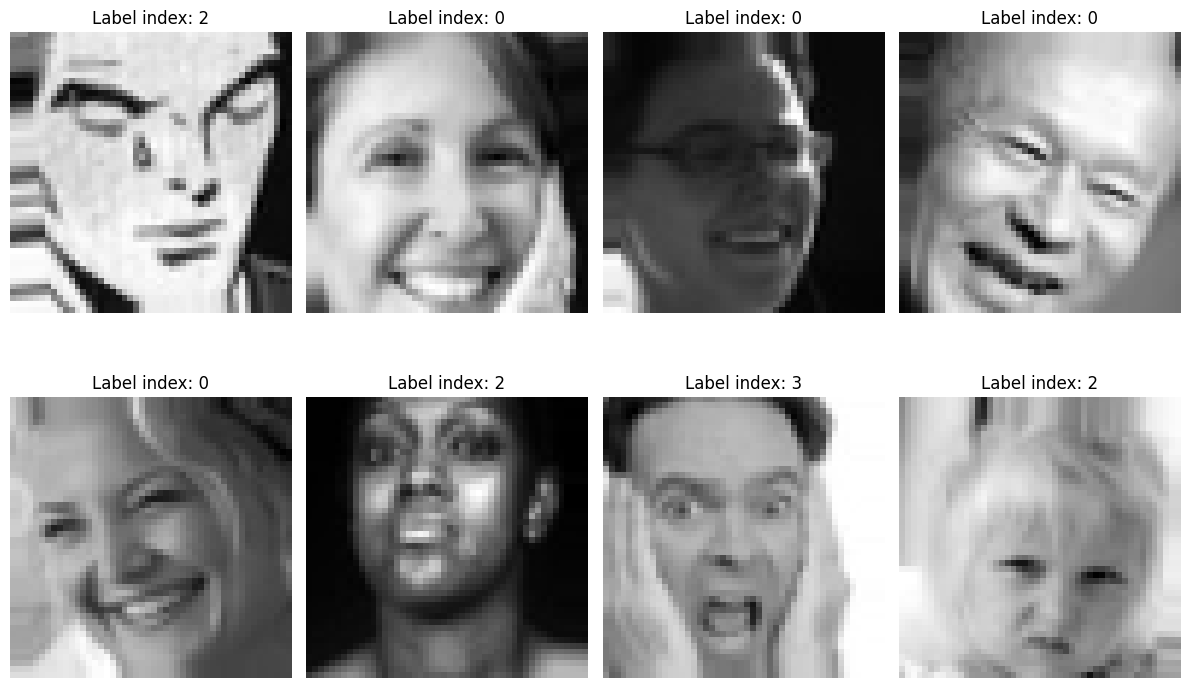%0A"
class="output-image" alt="Output" />

 

**Interpretation:** Pulling one batch from the training generator and
inspecting its shape. Image batch shape is 32 grayscale images, 48 by 48
sized images with 1 channel. Label batch shape is 32, 4. This confirms
the greyscale model input pipeline is correct.

 

### **Base Neural Network**

 

### **Model Building**

 

**Reasoning:** This defines the Baseline CNN model. Having a baseline
gives a reference point so later models can be measured.

In \[ \]:

    baseline_cnn = Sequential([ # Creates a sequencial model
        Input(shape=(48, 48, 1)), # Defines the input shape
        Conv2D(32, (3, 3), activation="relu", padding="same"), # Applies 32 filters each being 3x3
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Conv2D(64, (3, 3), activation="relu", padding="same"), # Now applies 64 filters
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Flatten(), # Converts 3d feature maps to 1d vector
        Dense(128, activation="relu"), # Fully connected layer with 128 neurons
        Dropout(0.4), # Randomly turns off 40% of neurons during training
        Dense(4, activation="softmax") # Final classification layer
    ])

    baseline_cnn.summary() # Prints the layer shapes, number of parameters and total trainable parameters

```
Model: "sequential"
```

```
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
```

```
 Total params: 1,199,108 (4.57 MB)
```

```
 Trainable params: 1,199,108 (4.57 MB)
```

```
 Non-trainable params: 0 (0.00 B)
```

 

**Interpretation:** Defines the baseline CNN and serves as a
architectural benchmark. It is a 2 convolution CNN. total params:
1,199,108, trainable params: 1,199,108. All the params are trainable.

 

### **Compiling and Training the Model**

 

**Reasoning:** Turns the baseline architecture into a trainable model
and fits it to the data.

In \[ \]:

    baseline_cnn.compile( # Prepares the model for training
        optimizer=Adam(learning_rate=0.0005), # Uses the adaptive gradient method to set the learning rate
        loss="categorical_crossentropy", # Loss function for multi-class classification
        metrics=["accuracy"] # Tracks accuracy during training
    )

    history_baseline = baseline_cnn.fit( # Starts training and returns a history object
        train_gen_gray, # Training generator
        validation_data=val_gen_gray, # Evaluates the model after each epoch
        epochs=25, # Maximum number of training cycles
        callbacks=make_callbacks(), # Applies the callback function
        verbose=1 # Prints training progress per epoch
    )

Epoch 1/25 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m22s\[0m 38ms/step - accuracy: 0.3638 - loss: 1.3196 - val_accuracy:
0.4852 - val_loss: 1.1957 - learning_rate: 5.0000e-04 Epoch 2/25
\[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m17s\[0m
36ms/step - accuracy: 0.4366 - loss: 1.2280 - val_accuracy: 0.5186 -
val_loss: 1.1311 - learning_rate: 5.0000e-04 Epoch 3/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.4888 - loss: 1.1593 - val_accuracy: 0.5921 - val_loss: 0.9939 -
learning_rate: 5.0000e-04 Epoch 4/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 31ms/step - accuracy:
0.5088 - loss: 1.1196 - val_accuracy: 0.6020 - val_loss: 0.9576 -
learning_rate: 5.0000e-04 Epoch 5/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5231 - loss: 1.0892 - val_accuracy: 0.6279 - val_loss: 0.9060 -
learning_rate: 5.0000e-04 Epoch 6/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5350 - loss: 1.0562 - val_accuracy: 0.6086 - val_loss: 0.9253 -
learning_rate: 5.0000e-04 Epoch 7/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5487 - loss: 1.0349 - val_accuracy: 0.6297 - val_loss: 0.8903 -
learning_rate: 5.0000e-04 Epoch 8/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5628 - loss: 1.0095 - val_accuracy: 0.6289 - val_loss: 0.8912 -
learning_rate: 5.0000e-04 Epoch 9/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5793 - loss: 0.9915 - val_accuracy: 0.6482 - val_loss: 0.8587 -
learning_rate: 5.0000e-04 Epoch 10/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5828 - loss: 0.9873 - val_accuracy: 0.6622 - val_loss: 0.8394 -
learning_rate: 5.0000e-04 Epoch 11/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5857 - loss: 0.9657 - val_accuracy: 0.6661 - val_loss: 0.8068 -
learning_rate: 5.0000e-04 Epoch 12/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5918 - loss: 0.9569 - val_accuracy: 0.6643 - val_loss: 0.8164 -
learning_rate: 5.0000e-04 Epoch 13/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.6009 - loss: 0.9402 - val_accuracy: 0.6681 - val_loss: 0.8033 -
learning_rate: 5.0000e-04 Epoch 14/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.6057 - loss: 0.9349 - val_accuracy: 0.6735 - val_loss: 0.7986 -
learning_rate: 5.0000e-04 Epoch 15/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.6146 - loss: 0.9145 - val_accuracy: 0.6717 - val_loss: 0.8087 -
learning_rate: 5.0000e-04 Epoch 16/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6163 - loss: 0.9073 - val_accuracy: 0.6813 - val_loss: 0.7813 -
learning_rate: 5.0000e-04 Epoch 17/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.6211 - loss: 0.8968 - val_accuracy: 0.6677 - val_loss: 0.8132 -
learning_rate: 5.0000e-04 Epoch 18/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 31ms/step - accuracy:
0.6225 - loss: 0.8960 - val_accuracy: 0.6854 - val_loss: 0.7676 -
learning_rate: 5.0000e-04 Epoch 19/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6300 - loss: 0.8838 - val_accuracy: 0.6886 - val_loss: 0.7600 -
learning_rate: 5.0000e-04 Epoch 20/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m20s\[0m 30ms/step - accuracy:
0.6333 - loss: 0.8734 - val_accuracy: 0.6719 - val_loss: 0.8039 -
learning_rate: 5.0000e-04 Epoch 21/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6364 - loss: 0.8717 - val_accuracy: 0.6916 - val_loss: 0.7529 -
learning_rate: 5.0000e-04 Epoch 22/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6364 - loss: 0.8649 - val_accuracy: 0.6874 - val_loss: 0.7573 -
learning_rate: 5.0000e-04 Epoch 23/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6410 - loss: 0.8516 - val_accuracy: 0.6918 - val_loss: 0.7448 -
learning_rate: 5.0000e-04 Epoch 24/25 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6380 - loss: 0.8587 - val_accuracy: 0.6928 - val_loss: 0.7487 -
learning_rate: 5.0000e-04 Epoch 25/25 \[1m472/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━\[0m\[37m━\[0m \[1m0s\[0m 26ms/step - accuracy:
0.6544 - loss: 0.8460 Epoch 25: ReduceLROnPlateau reducing learning rate
to 0.0002500000118743628. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.6495 - loss: 0.8462 - val_accuracy: 0.6803 - val_loss: 0.7857 -
learning_rate: 5.0000e-04 Restoring model weights from the end of the
best epoch: 23.

 

**Interpretation:** The model trained for 25 epochs with learning rate
reductions. The model weights were restored from epoch 23 suggesting
epochs 24 and 25 did not perform as well as epoch 23. The model appears
stable and generalized.

 

### **Evaluating the Model on the Test Set**

 

**Reasoning:** Thoroughly evaluates utilizing learning curves,
validation metrics, test metrics, a confusion matrix and classification
report.

In \[ \]:

    plot_history(history_baseline, "Baseline CNN") # Plots the training validation accuracy and loss

    val_loss_baseline, val_acc_baseline = evaluate_model( # Returns model validation data
        baseline_cnn, val_gen_gray, "Baseline CNN - Validation" # Accuracy and loss
    )
    test_loss_baseline, test_acc_baseline = evaluate_model( # Runs the model on unseen data
        baseline_cnn, test_gen_gray, "Baseline CNN - Test" # Accuracy and loss
    )

    classification_diagnostics(baseline_cnn, test_gen_gray, "Baseline CNN") # Predicts probabilities and converts class predictions, compares with true labels and builds the confusion matrix

<img
src="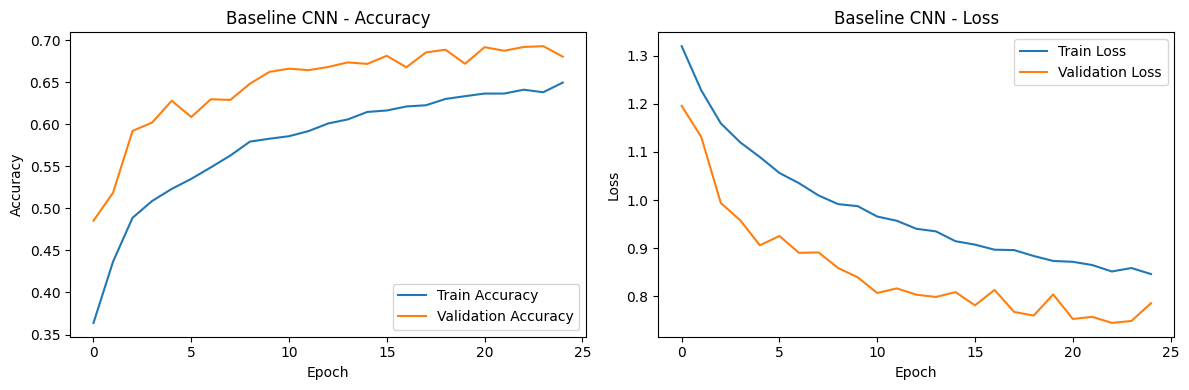%0A"
class="output-image" alt="Output" />

\[1m156/156\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m2s\[0m
10ms/step - accuracy: 0.6918 - loss: 0.7448 Baseline CNN - Validation
Loss: 0.7448 Baseline CNN - Validation Accuracy: 0.6918 \[1m4/4\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 13ms/step - accuracy:
0.7031 - loss: 0.6318 Baseline CNN - Test Loss: 0.6318 Baseline CNN -
Test Accuracy: 0.7031 \[1m4/4\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m0s\[0m 12ms/step

<img
src="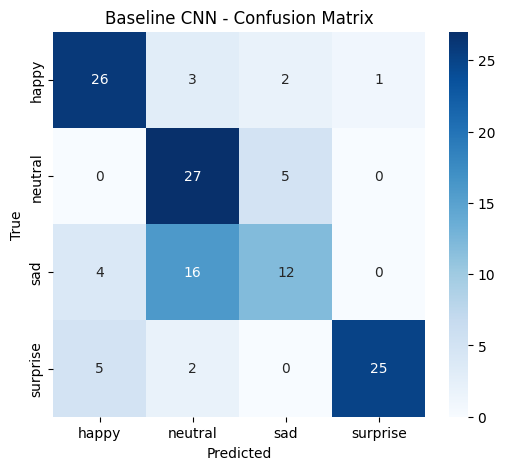%0A"
class="output-image" alt="Output" />

Baseline CNN Classification Report: precision recall f1-score support
happy 0.74 0.81 0.78 32 neutral 0.56 0.84 0.68 32 sad 0.63 0.38 0.47 32
surprise 0.96 0.78 0.86 32 accuracy 0.70 128 macro avg 0.72 0.70 0.70
128 weighted avg 0.72 0.70 0.70 128

 

**Interpretation:** The baseline model appears to do well. The model
appears to seperate out obvious expressions fairly well. However, it
does struggle with speration between neutral and sad. Suprise is
classified the strongest and sad as the weakest class.

 

### **Second Convolutional Neural Network**

 

### **Model Building**

 

**Reasoning:** The next architectural improvement add more depth and
more filters. It adds batch normalization and a larger dense layer. This
helps to improve feature extraction and training stability.

In \[ \]:

    second_cnn = Sequential([ # Creates sequential model
        Input(shape=(48, 48, 1)), # Applies 32 filters each being 3x3
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(), # Normalizes the output of the convolution layer
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(), # Normalizes the output of the convolution layer
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Conv2D(128, (3, 3), activation="relu", padding="same"), # Applies 128 filters
        BatchNormalization(), # Normalizes the output of the convolution layer
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Flatten(), # Creates a long feature vector
        Dense(256, activation="relu"), # Fully connected layer with 128 neurons
        Dropout(0.4), # Randomly disables 40%
        Dense(4, activation="softmax") # Goes from softmax to probability distribution
    ])

    second_cnn.summary() # Displays layer shapes and parameter counts

```
Model: "sequential_1"
```

```
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
```

```
 Total params: 1,274,500 (4.86 MB)
```

```
 Trainable params: 1,274,052 (4.86 MB)
```

```
 Non-trainable params: 448 (1.75 KB)
```

 

**Interpretation:** A stronger CNN than the baseline. There is one
additional convolution block, batch normalization and a larger dense
layer. This helps to improve training and stability in feature
extraction. total params: 1,274,500, trainable params: 1,274,052.

 

### **Compiling and Training the Model**

 

**Reasoning:** This tests if the deeper architecture performs better
than the baseline model. Consistency is kept in the training process to
determine if the differences can be attributed to the architecture.

In \[ \]:

    second_cnn.compile( # Prepares model for training
        optimizer=Adam(learning_rate=0.0005), # Uses the adaptive gradient method to set the learning rate
        loss="categorical_crossentropy", # Loss function for multi-class classification
        metrics=["accuracy"] # Tracks accuracy during training
    )

    history_second = second_cnn.fit( # Starts training and returns a history object
        train_gen_gray, # Training generator
        validation_data=val_gen_gray, # Evaluates the model after each epoch
        epochs=30, # Maximum number of training cycles
        callbacks=make_callbacks(), # Applies the callback function
        verbose=1 # Prints training progress per epoch
    )

Epoch 1/30 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m25s\[0m 40ms/step - accuracy: 0.3962 - loss: 1.3469 - val_accuracy:
0.4744 - val_loss: 1.1878 - learning_rate: 5.0000e-04 Epoch 2/30
\[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m
30ms/step - accuracy: 0.4933 - loss: 1.1333 - val_accuracy: 0.4159 -
val_loss: 1.2322 - learning_rate: 5.0000e-04 Epoch 3/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 31ms/step - accuracy:
0.5497 - loss: 1.0263 - val_accuracy: 0.5077 - val_loss: 1.1143 -
learning_rate: 5.0000e-04 Epoch 4/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.5893 - loss: 0.9619 - val_accuracy: 0.5937 - val_loss: 1.0365 -
learning_rate: 5.0000e-04 Epoch 5/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6194 - loss: 0.9117 - val_accuracy: 0.6004 - val_loss: 0.9878 -
learning_rate: 5.0000e-04 Epoch 6/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 31ms/step - accuracy:
0.6323 - loss: 0.8779 - val_accuracy: 0.6436 - val_loss: 0.8651 -
learning_rate: 5.0000e-04 Epoch 7/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 31ms/step - accuracy:
0.6452 - loss: 0.8545 - val_accuracy: 0.6514 - val_loss: 0.8461 -
learning_rate: 5.0000e-04 Epoch 8/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6609 - loss: 0.8192 - val_accuracy: 0.6934 - val_loss: 0.7570 -
learning_rate: 5.0000e-04 Epoch 9/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6681 - loss: 0.8026 - val_accuracy: 0.7119 - val_loss: 0.7108 -
learning_rate: 5.0000e-04 Epoch 10/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6770 - loss: 0.7903 - val_accuracy: 0.7095 - val_loss: 0.7182 -
learning_rate: 5.0000e-04 Epoch 11/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6785 - loss: 0.7797 - val_accuracy: 0.7163 - val_loss: 0.7012 -
learning_rate: 5.0000e-04 Epoch 12/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6883 - loss: 0.7590 - val_accuracy: 0.7073 - val_loss: 0.7434 -
learning_rate: 5.0000e-04 Epoch 13/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6910 - loss: 0.7540 - val_accuracy: 0.7273 - val_loss: 0.6907 -
learning_rate: 5.0000e-04 Epoch 14/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.6914 - loss: 0.7474 - val_accuracy: 0.6884 - val_loss: 0.7478 -
learning_rate: 5.0000e-04 Epoch 15/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 26ms/step - accuracy:
0.7045 - loss: 0.7162 Epoch 15: ReduceLROnPlateau reducing learning rate
to 0.0002500000118743628. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.7008 - loss: 0.7338 - val_accuracy: 0.7046 - val_loss: 0.7096 -
learning_rate: 5.0000e-04 Epoch 16/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.7203 - loss: 0.6972 - val_accuracy: 0.7251 - val_loss: 0.6756 -
learning_rate: 2.5000e-04 Epoch 17/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.7303 - loss: 0.6750 - val_accuracy: 0.7426 - val_loss: 0.6392 -
learning_rate: 2.5000e-04 Epoch 18/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.7280 - loss: 0.6658 - val_accuracy: 0.6594 - val_loss: 0.8821 -
learning_rate: 2.5000e-04 Epoch 19/30 \[1m471/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━\[0m\[37m━\[0m \[1m0s\[0m 26ms/step - accuracy:
0.7370 - loss: 0.6551 Epoch 19: ReduceLROnPlateau reducing learning rate
to 0.0001250000059371814. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.7351 - loss: 0.6572 - val_accuracy: 0.7408 - val_loss: 0.6490 -
learning_rate: 2.5000e-04 Epoch 20/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.7399 - loss: 0.6470 - val_accuracy: 0.7559 - val_loss: 0.6263 -
learning_rate: 1.2500e-04 Epoch 21/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.7462 - loss: 0.6310 - val_accuracy: 0.7505 - val_loss: 0.6577 -
learning_rate: 1.2500e-04 Epoch 22/30 \[1m472/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━\[0m\[37m━\[0m \[1m0s\[0m 26ms/step - accuracy:
0.7511 - loss: 0.6196 Epoch 22: ReduceLROnPlateau reducing learning rate
to 6.25000029685907e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.7478 - loss: 0.6225 - val_accuracy: 0.7440 - val_loss: 0.6368 -
learning_rate: 1.2500e-04 Epoch 23/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.7564 - loss: 0.6114 - val_accuracy: 0.7521 - val_loss: 0.6278 -
learning_rate: 6.2500e-05 Epoch 24/30 \[1m472/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━\[0m\[37m━\[0m \[1m0s\[0m 26ms/step - accuracy:
0.7515 - loss: 0.6150 Epoch 24: ReduceLROnPlateau reducing learning rate
to 3.125000148429535e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.7547 - loss: 0.6070 - val_accuracy: 0.7444 - val_loss: 0.6557 -
learning_rate: 6.2500e-05 Epoch 25/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 29ms/step - accuracy:
0.7598 - loss: 0.6015 - val_accuracy: 0.7535 - val_loss: 0.6307 -
learning_rate: 3.1250e-05 Epoch 26/30 \[1m471/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━\[0m\[37m━\[0m \[1m0s\[0m 26ms/step - accuracy:
0.7561 - loss: 0.5965 Epoch 26: ReduceLROnPlateau reducing learning rate
to 1.5625000742147677e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m14s\[0m 30ms/step - accuracy:
0.7599 - loss: 0.5946 - val_accuracy: 0.7507 - val_loss: 0.6551 -
learning_rate: 3.1250e-05 Epoch 26: early stopping Restoring model
weights from the end of the best epoch: 20.

 

**Interpretation:** The model trained for 30 epochs. The model weights
were restored from epoch 27. The model improved over the baseline model.
The training is stabalized and there is a lower validation loss. This
suggests the features extracted were more useful.

 

### **Evaluating the Model on the Test Set**

 

**Reasoning:** Evaluates if the additional complexity improved
generalization.

In \[ \]:

    plot_history(history_second, "Second CNN") # Plots the training validation accuracy and loss

    val_loss_second, val_acc_second = evaluate_model( # Returns model validation data
        second_cnn, val_gen_gray, "Second CNN - Validation" # Accuracy and loss
    )
    test_loss_second, test_acc_second = evaluate_model( # Runs the model on unseen data
        second_cnn, test_gen_gray, "Second CNN - Test" # Accuracy and loss
    )

    classification_diagnostics(second_cnn, test_gen_gray, "Second CNN") # Predicts probabilities and converts class predictions, compares with true labels and builds the confusion matrix

<img
src="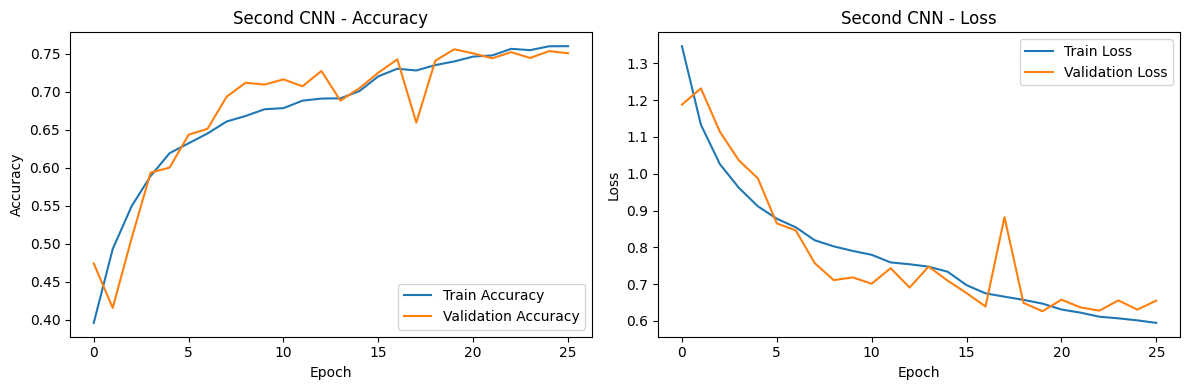%0A"
class="output-image" alt="Output" />

\[1m156/156\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m2s\[0m
10ms/step - accuracy: 0.7559 - loss: 0.6263 Second CNN - Validation
Loss: 0.6263 Second CNN - Validation Accuracy: 0.7559 \[1m4/4\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 14ms/step - accuracy:
0.8047 - loss: 0.4958 Second CNN - Test Loss: 0.4958 Second CNN - Test
Accuracy: 0.8047 \[1m4/4\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m1s\[0m 10ms/step

<img
src="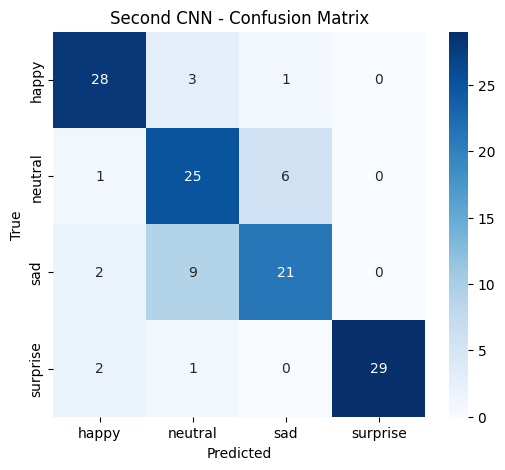%0A"
class="output-image" alt="Output" />

Second CNN Classification Report: precision recall f1-score support
happy 0.85 0.88 0.86 32 neutral 0.66 0.78 0.71 32 sad 0.75 0.66 0.70 32
surprise 1.00 0.91 0.95 32 accuracy 0.80 128 macro avg 0.81 0.80 0.81
128 weighted avg 0.81 0.80 0.81 128

 

**Interpretation:** The model is much more reliable than the baseline.
There is stronger accuracy, improved sad performance, great on suprise
class, and better balance across classes.

 

### **Transfer Learning Architectures**

  

 

**Reasoning:** Creates a reusable preprocessing pipeline for transfer
learning models. This reduces the need for a custom generator for each
model.

In \[ \]:

    def make_tl_generators(preprocess_fn, img_size=224, batch_size=32): # Defines the function to create data generators
        train_datagen = ImageDataGenerator( # Creating an image data generator for training data
            preprocessing_function=preprocess_fn, # Applying model specific preprocessing
            rotation_range=10, # Randomly rotate image up to 10 degrees
            width_shift_range=0.1, # Randomly shift image horizontally up to 10%
            height_shift_range=0.1, # Randomly shift image vertically up to 10%
            zoom_range=0.1, # Randomly zoom in/out by up to 20%
            horizontal_flip=True # Randomly flip images horizontally
        )

        val_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn) # Creates validation generator with only preprocessing
        test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn) # Create test generator with only preprocessing

        train_gen = train_datagen.flow_from_directory( # Loads training image from directory
            train_dir, # Path to training dataset
            target_size=(img_size, img_size), # Resize all image to specified size
            color_mode="rgb", # Loads image as 3 channel RGB
            batch_size=batch_size, # Number of images per batch
            class_mode="categorical", # Use one-hot encoding labels
            shuffle=True, # Shuffle data each epoch
            seed=SEED # Set random seed for reproducibility
        )

        val_gen = val_datagen.flow_from_directory( # Loadss validation images
            val_dir, # Path to validation dataset
            target_size=(img_size, img_size), # Resize images to same size as training
            color_mode="rgb", # Uses RGB format
            batch_size=batch_size, # Same batch size as training
            class_mode="categorical", # One-hot encoding labels
            shuffle=False # Do not shuffle
        )

        test_gen = test_datagen.flow_from_directory( # Loads test images
            test_dir, # Path to test dataset
            target_size=(img_size, img_size), # Resizes image consistently
            color_mode="rgb", # Uses RGB format
            batch_size=batch_size, # Batch size for testing
            class_mode="categorical", # One-hot encoded labels
            shuffle=False # Do not shuffle
        )

        return train_gen, val_gen, test_gen # Returns all three generators for training and validation

 

**Interpretation:** Creates RGB generators for transfer learning models.
It applies model specific preprocessing and larger input size of 224 by
224. It preserves modular code and prevents repetition. Only taining
data will be augmented.

 

### **VGG16 Model**

 

### **Importing the VGG16 Architecture**

 

**Reasoning:** Manually builds a VGG specific pipeline. It serves the
same purpose as the make_tl_generators but is tailored specifically to
VGG16 preprocessing.

In \[ \]:

    IMG_SIZE_VGG = 224 # Sets the image size to 224x224
    BATCH_SIZE_VGG = 32 # Defines number of images processed per batch

    def find_dataset_root(base_path): # Defines function to locate dataset root folder
        for root, dirs, files in os.walk(base_path): # Walk through all directories recursively
            if {'train', 'validation', 'test'}.issubset(set(dirs)): # Checks if required subfolders exist
                return root # Returns the folder that contains train/validation/test
        return None # Returns None if no dataset structure is found

    extract_path = "/content/facial_emotion_data" # Path where dataset was extracted
    dataset_root = find_dataset_root(extract_path) # Find the correct dataset root dynamically

    if dataset_root: # If root is found
        train_dir = os.path.join(dataset_root, "train") # Path to training data
        val_dir = os.path.join(dataset_root, "validation") # Path to validation data
        test_dir = os.path.join(dataset_root, "test") # Path to test data
    else:
        raise FileNotFoundError("Could not locate dataset folders. Please ensure the extraction cell was run.") # Stop execution if dataset not found

    train_datagen_vgg = ImageDataGenerator( # Create training data generator with augmentation
        preprocessing_function=vgg16_preprocess, # Apply VGG16 specific preprocessing
        rotation_range=10, # Randomly rodates image up to 10%
        width_shift_range=0.1, # Randomly shift image horizontally up to 10%
        height_shift_range=0.1, # Randomly shift image vertically up to 10%
        zoom_range=0.1, # Randomly zoom in/out up to 10%
        horizontal_flip=True # Randomly flig images horizontally
    )

    val_test_datagen_vgg = ImageDataGenerator( # Creates generator for valisation and test data
        preprocessing_function=vgg16_preprocess # Applies same preprocessing but no augmentation
    )

    train_gen_vgg = train_datagen_vgg.flow_from_directory( # Loads training image from directory
        train_dir, # Path to training folder
        target_size=(IMG_SIZE_VGG, IMG_SIZE_VGG), # Resizes to 224x224
        color_mode="rgb", # Uses RGB format
        batch_size=BATCH_SIZE_VGG, # Batch size
        class_mode="categorical", # One-hot encoded labels
        shuffle=True, # Do not shuffle
        seed=42 # Set random seed for reproducibility
    )

    val_gen_vgg = val_test_datagen_vgg.flow_from_directory( # Loads validaiton images
        val_dir, # Path to validation folder
        target_size=(IMG_SIZE_VGG, IMG_SIZE_VGG), # Resizes to 224x224
        color_mode="rgb", # Uses RGB format
        batch_size=BATCH_SIZE_VGG, # Batch size
        class_mode="categorical", # One-hot encoded labels
        shuffle=False # Do not shuffle
    )

    test_gen_vgg = val_test_datagen_vgg.flow_from_directory( # Loads test images
        test_dir, # Path to test folder
        target_size=(IMG_SIZE_VGG, IMG_SIZE_VGG), # Resizes to 224x224
        color_mode="rgb", # Uses RGB format
        batch_size=BATCH_SIZE_VGG, # Batch size
        class_mode="categorical", # One-hot encoded labels
        shuffle=False # Do not shuffle
    )

    print("Class indices:", train_gen_vgg.class_indices) # Prints mapping of class names to numeric labels

Found 15109 images belonging to 4 classes. Found 4977 images belonging
to 4 classes. Found 128 images belonging to 4 classes. Class indices:
{'happy': 0, 'neutral': 1, 'sad': 2, 'surprise': 3}

 

**Interpretation:** Confirms transfer learning pipeline for VGG16 is
aligned with the same class mapping as the grayscale models. Training:
15, 109, validation: 4,977, test: 128.

 

### **Model Building**

  

 

**Reasoning:** This constructs the actual VGG16 transfer learning model.

In \[ \]:

    train_gen_vgg, val_gen_vgg, test_gen_vgg = make_tl_generators(vgg16_preprocess) # Calls transfer learning generator and returns training, validation, and test generators

    base_model_vgg = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3)) # Loads pretrained weights, excludes original classification head abd defines input shape
    base_model_vgg.trainable = False # Freezes all layers in basemodel so pretrained weights are not updated

    vgg16_model = Sequential([ # Adds pretrained convolutional base
        base_model_vgg, # As feature extractor
        GlobalAveragePooling2D(), # Converts feature maps into a single vector and reduces parameters
        Dense(128, activation="relu"), # Fully connected layer with 128 neurons
        Dropout(0.4), # Randomly drops 40% of neurons during training
        Dense(4, activation="softmax") # Output layer with 4 neurons
    ])

Found 15109 images belonging to 4 classes. Found 4977 images belonging
to 4 classes. Found 128 images belonging to 4 classes. Downloading data
from
https://storage.googleapis.com/tensorflow/keras-applications/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5
\[1m58889256/58889256\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m5s\[0m 0us/step

 

**Interpretation:** Builds a frozen reature transfer learning model
where only the top classifier learns. This reduces training time and the
risk of overfitting.

 

### **Compiling and Training the VGG16 Model**

 

**Reasoning:** Trains the VGG16 model with a smaller learning rate
because pretrained backbones are more sensitive.

In \[ \]:

    vgg16_model.compile( # Prepares the model for training
        optimizer=Adam(learning_rate=0.0001), # Uses the adaptive gradient method to set the learning rate
        loss="categorical_crossentropy", # Loss function for multi-class classification
        metrics=["accuracy"] # Tracks accuracy during training
    )

    history_vgg = vgg16_model.fit( # Starts training and returns a history object
        train_gen_vgg, # Training generator
        validation_data=val_gen_vgg, # Evaluates the model after each epoch
        epochs=20, # Maximum number of training cycles
        callbacks=make_callbacks(), # Applies the callback function
        verbose=1 # Prints training progress per epoch
    )

Epoch 1/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m275s\[0m 542ms/step - accuracy: 0.3230 - loss: 1.8850 -
val_accuracy: 0.3828 - val_loss: 1.3244 - learning_rate: 1.0000e-04
Epoch 2/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m239s\[0m 506ms/step - accuracy: 0.3828 - loss: 1.3134 -
val_accuracy: 0.4111 - val_loss: 1.2543 - learning_rate: 1.0000e-04
Epoch 3/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m267s\[0m 517ms/step - accuracy: 0.4172 - loss: 1.2570 -
val_accuracy: 0.4402 - val_loss: 1.2162 - learning_rate: 1.0000e-04
Epoch 4/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m242s\[0m 511ms/step - accuracy: 0.4367 - loss: 1.2287 -
val_accuracy: 0.4619 - val_loss: 1.1901 - learning_rate: 1.0000e-04
Epoch 5/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m244s\[0m 517ms/step - accuracy: 0.4607 - loss: 1.1976 -
val_accuracy: 0.4776 - val_loss: 1.1745 - learning_rate: 1.0000e-04
Epoch 6/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m238s\[0m 503ms/step - accuracy: 0.4659 - loss: 1.1823 -
val_accuracy: 0.4736 - val_loss: 1.1712 - learning_rate: 1.0000e-04
Epoch 7/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m247s\[0m 522ms/step - accuracy: 0.4694 - loss: 1.1730 -
val_accuracy: 0.4947 - val_loss: 1.1377 - learning_rate: 1.0000e-04
Epoch 8/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m243s\[0m 514ms/step - accuracy: 0.4874 - loss: 1.1548 -
val_accuracy: 0.4874 - val_loss: 1.1436 - learning_rate: 1.0000e-04
Epoch 9/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m240s\[0m 508ms/step - accuracy: 0.4913 - loss: 1.1428 -
val_accuracy: 0.4941 - val_loss: 1.1360 - learning_rate: 1.0000e-04
Epoch 10/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m245s\[0m 517ms/step - accuracy: 0.5050 - loss: 1.1270 -
val_accuracy: 0.5025 - val_loss: 1.1293 - learning_rate: 1.0000e-04
Epoch 11/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m242s\[0m 511ms/step - accuracy: 0.5072 - loss: 1.1193 -
val_accuracy: 0.5047 - val_loss: 1.1162 - learning_rate: 1.0000e-04
Epoch 12/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m259s\[0m 504ms/step - accuracy: 0.5142 - loss: 1.1092 -
val_accuracy: 0.5148 - val_loss: 1.1050 - learning_rate: 1.0000e-04
Epoch 13/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m238s\[0m 502ms/step - accuracy: 0.5163 - loss: 1.1008 -
val_accuracy: 0.5214 - val_loss: 1.0998 - learning_rate: 1.0000e-04
Epoch 14/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m240s\[0m 506ms/step - accuracy: 0.5211 - loss: 1.0940 -
val_accuracy: 0.5256 - val_loss: 1.0903 - learning_rate: 1.0000e-04
Epoch 15/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m237s\[0m 500ms/step - accuracy: 0.5292 - loss: 1.0864 -
val_accuracy: 0.5294 - val_loss: 1.0830 - learning_rate: 1.0000e-04
Epoch 16/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m247s\[0m 521ms/step - accuracy: 0.5326 - loss: 1.0810 -
val_accuracy: 0.5294 - val_loss: 1.0891 - learning_rate: 1.0000e-04
Epoch 17/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m0s\[0m 451ms/step - accuracy: 0.5329 - loss: 1.0773 Epoch 17:
ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
\[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m260s\[0m
517ms/step - accuracy: 0.5348 - loss: 1.0728 - val_accuracy: 0.5337 -
val_loss: 1.0832 - learning_rate: 1.0000e-04 Epoch 18/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m240s\[0m 508ms/step -
accuracy: 0.5418 - loss: 1.0700 - val_accuracy: 0.5371 - val_loss:
1.0744 - learning_rate: 5.0000e-05 Epoch 19/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m243s\[0m 513ms/step -
accuracy: 0.5421 - loss: 1.0626 - val_accuracy: 0.5375 - val_loss:
1.0773 - learning_rate: 5.0000e-05 Epoch 20/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 447ms/step - accuracy:
0.5320 - loss: 1.0699 Epoch 20: ReduceLROnPlateau reducing learning rate
to 2.499999936844688e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m242s\[0m 512ms/step -
accuracy: 0.5358 - loss: 1.0649 - val_accuracy: 0.5337 - val_loss:
1.0796 - learning_rate: 5.0000e-05 Restoring model weights from the end
of the best epoch: 18.

 

**Interpretation:** The model is trained for 20 epochs. The model
weights were restored from epoch 18. Suggesting epochs 19 and 20 did not
perform as well as epoch 18. The model was much slower and underpermed
compared the the Custom CNN models. This could be due to the feature
extraction being frozen and the VGG16 model being older and heavier.

 

### **Evaluating the VGG16 model**

 

**Reasoning:** Determines if the VGG16 model is competitive.

In \[ \]:

    plot_history(history_vgg, "VGG16") # Plots the training validation accuracy and loss

    val_loss_vgg, val_acc_vgg = evaluate_model(vgg16_model, val_gen_vgg, "VGG16 - Validation") # Returns model validation data on accuracy and loss
    test_loss_vgg, test_acc_vgg = evaluate_model(vgg16_model, test_gen_vgg, "VGG16 - Test") # Returns model test data on accuracy and loss

    classification_diagnostics(vgg16_model, test_gen_vgg, "VGG16") # Predicts probabilities and converts class predictions, compares with true labels and builds the confusion matrix

<img
src="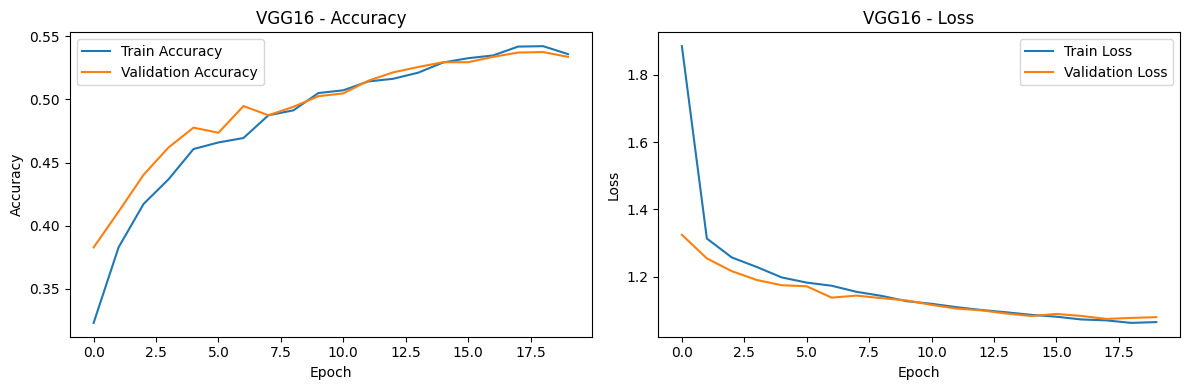%0A"
class="output-image" alt="Output" />

\[1m156/156\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m30s\[0m
192ms/step - accuracy: 0.5371 - loss: 1.0744 VGG16 - Validation Loss:
1.0744 VGG16 - Validation Accuracy: 0.5371 \[1m4/4\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m1s\[0m 194ms/step - accuracy:
0.6250 - loss: 0.9764 VGG16 - Test Loss: 0.9764 VGG16 - Test Accuracy:
0.6250 \[1m4/4\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m2s\[0m
197ms/step

<img
src="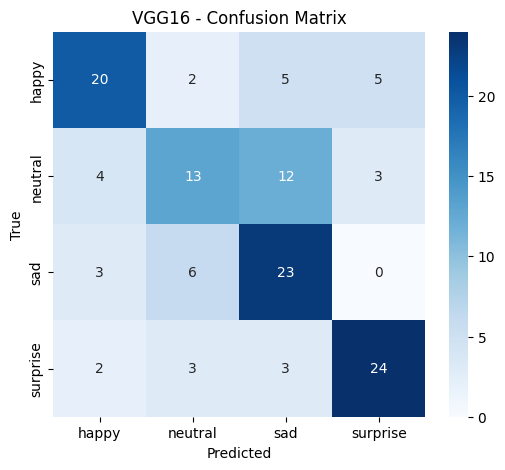%0A"
class="output-image" alt="Output" />

VGG16 Classification Report: precision recall f1-score support happy
0.69 0.62 0.66 32 neutral 0.54 0.41 0.46 32 sad 0.53 0.72 0.61 32
surprise 0.75 0.75 0.75 32 accuracy 0.62 128 macro avg 0.63 0.62 0.62
128 weighted avg 0.63 0.62 0.62 128

 

**Interpretation:** The model appears slower and less accurate. This
means that the model is not competitive. It seems the dataset is better
suited for taks specific grayscale Custom CNN model features than frozen
RGB imageNet features.

 

### **ResNet V2 Model**

 

### **Model Building**

 

**Reasoning:** Builds the ResNet50V2 transfer learning model. ResNet50V2
is usually stronger because of the deeper architecture.

In \[ \]:

    train_gen_resnet, val_gen_resnet, test_gen_resnet = make_tl_generators(resnet_preprocess) # Create training, validation, and test generators

    base_model_resnet = ResNet50V2(weights="imagenet", include_top=False, input_shape=(224, 224, 3)) # Loads pretrained weights, excludes original classification head abd defines input shape
    base_model_resnet.trainable = False # Freezes all layers in basemodel so pretrained weights are not updated

    resnet_model = Sequential([ # Adds pretrained convolutional base
        base_model_resnet, # As feature extractor
        GlobalAveragePooling2D(), # Converts feature maps into a single vector and reduces parameters
        Dense(128, activation="relu"), # Fully connected layer with 128 neurons
        Dropout(0.4), # Randomly drops 40% of neurons during training
        Dense(4, activation="softmax") # Output layer with 4 neurons
    ])

Found 15109 images belonging to 4 classes. Found 4977 images belonging
to 4 classes. Found 128 images belonging to 4 classes. Downloading data
from
https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50v2_weights_tf_dim_ordering_tf_kernels_notop.h5
\[1m94668760/94668760\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m7s\[0m 0us/step

 

**Interpretation:** This builds the ResNet50V2 transfer learning model.

 

### **Compiling and Training the Model**

 

**Reasoning:** Trains the ResNet50V2 under the same framework as the
other models to allow a fair comparison.

In \[ \]:

    resnet_model.compile( # Prepares the model for training
        optimizer=Adam(learning_rate=0.0001), # Uses the adaptive gradient method to set the learning rate
        loss="categorical_crossentropy", # Loss function for multi-class classification
        metrics=["accuracy"] # Tracks accuracy during training
    )

    history_resnet = resnet_model.fit( # Starts training and returns a history object
        train_gen_resnet, # Training generator
        validation_data=val_gen_resnet, # Evaluates the model after each epoch
        epochs=20, # Maximum number of training cycles
        callbacks=make_callbacks(), # Applies the callback function
        verbose=1 # Prints training progress per epoch
    )

Epoch 1/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m241s\[0m 480ms/step - accuracy: 0.4532 - loss: 1.2395 -
val_accuracy: 0.5915 - val_loss: 0.9864 - learning_rate: 1.0000e-04
Epoch 2/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m210s\[0m 444ms/step - accuracy: 0.5634 - loss: 1.0361 -
val_accuracy: 0.6241 - val_loss: 0.9189 - learning_rate: 1.0000e-04
Epoch 3/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m205s\[0m 432ms/step - accuracy: 0.5951 - loss: 0.9710 -
val_accuracy: 0.6440 - val_loss: 0.8721 - learning_rate: 1.0000e-04
Epoch 4/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m207s\[0m 437ms/step - accuracy: 0.6124 - loss: 0.9340 -
val_accuracy: 0.6518 - val_loss: 0.8570 - learning_rate: 1.0000e-04
Epoch 5/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m210s\[0m 444ms/step - accuracy: 0.6262 - loss: 0.9145 -
val_accuracy: 0.6645 - val_loss: 0.8360 - learning_rate: 1.0000e-04
Epoch 6/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m209s\[0m 440ms/step - accuracy: 0.6324 - loss: 0.8957 -
val_accuracy: 0.6725 - val_loss: 0.8225 - learning_rate: 1.0000e-04
Epoch 7/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m206s\[0m 435ms/step - accuracy: 0.6432 - loss: 0.8794 -
val_accuracy: 0.6707 - val_loss: 0.8139 - learning_rate: 1.0000e-04
Epoch 8/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m206s\[0m 435ms/step - accuracy: 0.6481 - loss: 0.8669 -
val_accuracy: 0.6771 - val_loss: 0.8017 - learning_rate: 1.0000e-04
Epoch 9/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m207s\[0m 438ms/step - accuracy: 0.6558 - loss: 0.8499 -
val_accuracy: 0.6829 - val_loss: 0.7883 - learning_rate: 1.0000e-04
Epoch 10/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m203s\[0m 430ms/step - accuracy: 0.6556 - loss: 0.8400 -
val_accuracy: 0.6743 - val_loss: 0.7932 - learning_rate: 1.0000e-04
Epoch 11/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m203s\[0m 429ms/step - accuracy: 0.6623 - loss: 0.8327 -
val_accuracy: 0.6817 - val_loss: 0.7866 - learning_rate: 1.0000e-04
Epoch 12/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m205s\[0m 433ms/step - accuracy: 0.6618 - loss: 0.8266 -
val_accuracy: 0.6753 - val_loss: 0.7877 - learning_rate: 1.0000e-04
Epoch 13/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m205s\[0m 433ms/step - accuracy: 0.6713 - loss: 0.8105 -
val_accuracy: 0.6878 - val_loss: 0.7771 - learning_rate: 1.0000e-04
Epoch 14/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m208s\[0m 440ms/step - accuracy: 0.6754 - loss: 0.8076 -
val_accuracy: 0.6984 - val_loss: 0.7589 - learning_rate: 1.0000e-04
Epoch 15/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m205s\[0m 434ms/step - accuracy: 0.6783 - loss: 0.7995 -
val_accuracy: 0.6972 - val_loss: 0.7573 - learning_rate: 1.0000e-04
Epoch 16/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m204s\[0m 430ms/step - accuracy: 0.6777 - loss: 0.7930 -
val_accuracy: 0.6976 - val_loss: 0.7572 - learning_rate: 1.0000e-04
Epoch 17/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m203s\[0m 429ms/step - accuracy: 0.6793 - loss: 0.7912 -
val_accuracy: 0.6992 - val_loss: 0.7509 - learning_rate: 1.0000e-04
Epoch 18/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m206s\[0m 435ms/step - accuracy: 0.6818 - loss: 0.7901 -
val_accuracy: 0.7002 - val_loss: 0.7448 - learning_rate: 1.0000e-04
Epoch 19/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m205s\[0m 433ms/step - accuracy: 0.6914 - loss: 0.7762 -
val_accuracy: 0.7012 - val_loss: 0.7393 - learning_rate: 1.0000e-04
Epoch 20/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m202s\[0m 427ms/step - accuracy: 0.6863 - loss: 0.7753 -
val_accuracy: 0.6960 - val_loss: 0.7423 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 19.

 

**Interpretation:** The model trained for 20 epochs. The model weights
were restored from epoch 19 suggesting that epoch 20 did not perform as
well as epoch 19. The ResNet50V2 model appears to have performed better
than the VGG16 model and came close to performing as well as the Custom
Baseline CNN model on validation. It trained much more slowly than the
grayscale CNN but extracted better features than the VGG16 model.

 

### **Evaluating the ResNet Model**

 

**Reasoning:** Evaluates if the ResNet50V2 model generalizes better than
the previous models.

In \[ \]:

    plot_history(history_resnet, "ResNet50V2") # Plots the training validation accuracy and loss

    val_loss_resnet, val_acc_resnet = evaluate_model( # Returns model validation data
        resnet_model, val_gen_resnet, "ResNet50V2 - Validation" # Accuracy and loss
    )
    test_loss_resnet, test_acc_resnet = evaluate_model( # Runs the model on unseen data
        resnet_model, test_gen_resnet, "ResNet50V2 - Test" # Accuracy and loss
    )

    classification_diagnostics(resnet_model, test_gen_resnet, "ResNet50V2") # Predicts probabilities and converts class predictions, compares with true labels and builds the confusion matrix

<img
src="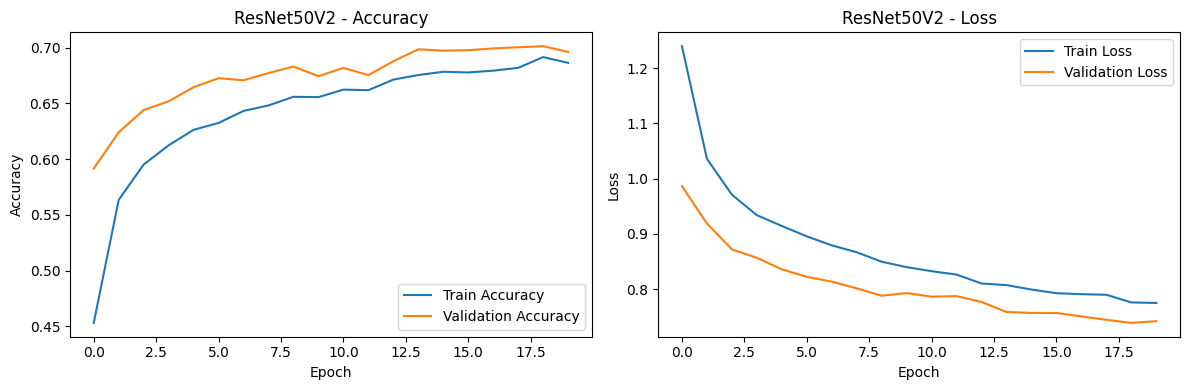%0A"
class="output-image" alt="Output" />

\[1m156/156\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m13s\[0m
81ms/step - accuracy: 0.7012 - loss: 0.7393 ResNet50V2 - Validation
Loss: 0.7393 ResNet50V2 - Validation Accuracy: 0.7012 \[1m4/4\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 83ms/step - accuracy:
0.7031 - loss: 0.7061 ResNet50V2 - Test Loss: 0.7061 ResNet50V2 - Test
Accuracy: 0.7031 \[1m4/4\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m4s\[0m 95ms/step

<img
src="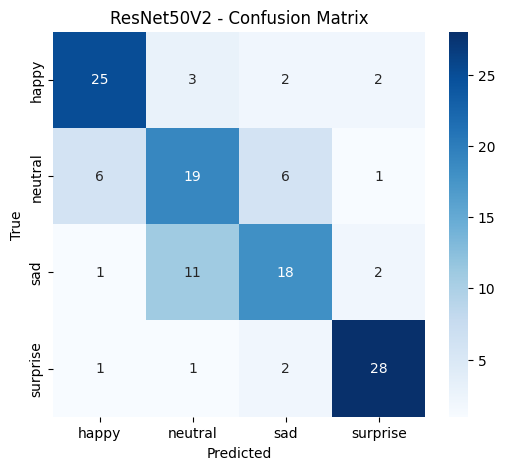%0A"
class="output-image" alt="Output" />

ResNet50V2 Classification Report: precision recall f1-score support
happy 0.76 0.78 0.77 32 neutral 0.56 0.59 0.58 32 sad 0.64 0.56 0.60 32
surprise 0.85 0.88 0.86 32 accuracy 0.70 128 macro avg 0.70 0.70 0.70
128 weighted avg 0.70 0.70 0.70 128

 

**Interpretation:** Although it performed well. It did not perform
better than the Custom CNN models. It is balanced but has lower test
accuracy. This suggests that transfer learning is not superior for this
dataset.

 

### **EfficientNet Model**

 

### **Model Building**

 

**Reasoning:** Builds the EfficientNetB0 transfer learning model to be
compared to the other architectures.

In \[ \]:

    train_gen_eff, val_gen_eff, test_gen_eff = make_tl_generators(efficientnet_preprocess) # Create training, validation, and test generators

    base_model_eff = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3)) # Loads pretrained weights, excludes original classification head abd defines input shape
    base_model_eff.trainable = False # Freezes all layers in basemodel so pretrained weights are not updated

    efficientnet_model = Sequential([ # Adds pretrained convolutional base
        base_model_eff, # As feature extractor
        GlobalAveragePooling2D(), # Converts feature maps into a single vector and reduces parameters
        Dense(128, activation="relu"), # Fully connected layer with 128 neurons
        Dropout(0.4), # Randomly drops 40% of neurons during training
        Dense(4, activation="softmax") # Output layer with 4 neurons
    ])

Found 15109 images belonging to 4 classes. Found 4977 images belonging
to 4 classes. Found 128 images belonging to 4 classes. Downloading data
from
https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5
\[1m16705208/16705208\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m2s\[0m 0us/step

 

**Interpretation:** Builds the EfficientNet transfer learning model.
Also, with the frozen backbone strategy VGG16 and ResNet50V2 transfer
learning models used.

 

### **Compiling and Training the Model**

 

**Reasoning:** Trains the EfficientNetBO model in the same framework to
test if it is a more efficient pretrained model.

In \[ \]:

    efficientnet_model.compile( # Prepares the model for training
        optimizer=Adam(learning_rate=0.0001), # Uses the adaptive gradient method to set the learning rate
        loss="categorical_crossentropy", # Loss function for multi-class classification
        metrics=["accuracy"] # Tracks accuracy during training
    )

    history_eff = efficientnet_model.fit( # Starts training and returns a history object
        train_gen_eff, # Training generator
        validation_data=val_gen_eff, # Evaluates the model after each epoch
        epochs=20, # Maximum number of training cycles
        callbacks=make_callbacks(), # Applies the callback function
        verbose=1 # Prints training progress per epoch
    )

Epoch 1/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m250s\[0m 468ms/step - accuracy: 0.4247 - loss: 1.2512 -
val_accuracy: 0.4770 - val_loss: 1.1695 - learning_rate: 1.0000e-04
Epoch 2/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m190s\[0m 401ms/step - accuracy: 0.5181 - loss: 1.1136 -
val_accuracy: 0.5114 - val_loss: 1.0997 - learning_rate: 1.0000e-04
Epoch 3/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m187s\[0m 396ms/step - accuracy: 0.5467 - loss: 1.0599 -
val_accuracy: 0.5053 - val_loss: 1.1119 - learning_rate: 1.0000e-04
Epoch 4/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m191s\[0m 404ms/step - accuracy: 0.5642 - loss: 1.0347 -
val_accuracy: 0.5558 - val_loss: 1.0459 - learning_rate: 1.0000e-04
Epoch 5/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m187s\[0m 395ms/step - accuracy: 0.5717 - loss: 1.0092 -
val_accuracy: 0.5194 - val_loss: 1.0797 - learning_rate: 1.0000e-04
Epoch 6/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m206s\[0m 405ms/step - accuracy: 0.5796 - loss: 0.9961 -
val_accuracy: 0.5795 - val_loss: 1.0073 - learning_rate: 1.0000e-04
Epoch 7/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m189s\[0m 400ms/step - accuracy: 0.5846 - loss: 0.9881 -
val_accuracy: 0.5754 - val_loss: 1.0102 - learning_rate: 1.0000e-04
Epoch 8/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m191s\[0m 403ms/step - accuracy: 0.5967 - loss: 0.9671 -
val_accuracy: 0.5953 - val_loss: 0.9821 - learning_rate: 1.0000e-04
Epoch 9/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m190s\[0m 402ms/step - accuracy: 0.6000 - loss: 0.9555 -
val_accuracy: 0.5941 - val_loss: 0.9726 - learning_rate: 1.0000e-04
Epoch 10/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m188s\[0m 397ms/step - accuracy: 0.6024 - loss: 0.9446 -
val_accuracy: 0.5767 - val_loss: 0.9943 - learning_rate: 1.0000e-04
Epoch 11/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m187s\[0m 394ms/step - accuracy: 0.6065 - loss: 0.9482 -
val_accuracy: 0.5957 - val_loss: 0.9668 - learning_rate: 1.0000e-04
Epoch 12/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m186s\[0m 393ms/step - accuracy: 0.6125 - loss: 0.9350 -
val_accuracy: 0.5686 - val_loss: 1.0110 - learning_rate: 1.0000e-04
Epoch 13/20 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m0s\[0m 380ms/step - accuracy: 0.6185 - loss: 0.9174 Epoch 13:
ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
\[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m187s\[0m
394ms/step - accuracy: 0.6152 - loss: 0.9230 - val_accuracy: 0.5921 -
val_loss: 0.9692 - learning_rate: 1.0000e-04 Epoch 14/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m186s\[0m 393ms/step -
accuracy: 0.6216 - loss: 0.9179 - val_accuracy: 0.6034 - val_loss:
0.9514 - learning_rate: 5.0000e-05 Epoch 15/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m185s\[0m 391ms/step -
accuracy: 0.6210 - loss: 0.9097 - val_accuracy: 0.5895 - val_loss:
0.9681 - learning_rate: 5.0000e-05 Epoch 16/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 384ms/step - accuracy:
0.6177 - loss: 0.9143 Epoch 16: ReduceLROnPlateau reducing learning rate
to 2.499999936844688e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m189s\[0m 398ms/step -
accuracy: 0.6186 - loss: 0.9128 - val_accuracy: 0.5937 - val_loss:
0.9640 - learning_rate: 5.0000e-05 Epoch 17/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m189s\[0m 399ms/step -
accuracy: 0.6219 - loss: 0.9071 - val_accuracy: 0.6034 - val_loss:
0.9470 - learning_rate: 2.5000e-05 Epoch 18/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m203s\[0m 401ms/step -
accuracy: 0.6300 - loss: 0.8964 - val_accuracy: 0.6018 - val_loss:
0.9490 - learning_rate: 2.5000e-05 Epoch 19/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 386ms/step - accuracy:
0.6346 - loss: 0.8872 Epoch 19: ReduceLROnPlateau reducing learning rate
to 1.249999968422344e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m189s\[0m 399ms/step -
accuracy: 0.6270 - loss: 0.8976 - val_accuracy: 0.5909 - val_loss:
0.9626 - learning_rate: 2.5000e-05 Epoch 20/20 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m190s\[0m 403ms/step -
accuracy: 0.6262 - loss: 0.9023 - val_accuracy: 0.5943 - val_loss:
0.9548 - learning_rate: 1.2500e-05 Restoring model weights from the end
of the best epoch: 17.

 

**Interpretation:** The model was set to train for 20 epochs and early
stopping occured at epoch 19. The model weights were restored from epoch
13 suggesting epoch 14-19 did not perform as well as epoch 13. The
EfficientNet model did not generalize well and early stopping suggests
that the model plateued and failed to improve. It appears better than
the VGG16 model on efficiency. However, it does not outperform the
Custom CNN models.

 

**Reasoning:** Measures if the EfficientNetBO model transfers well to
the dataset and compares to the other models.

In \[ \]:

    plot_history(history_eff, "EfficientNetB0") # Plots the training validation accuracy and loss

    val_loss_eff, val_acc_eff = evaluate_model( # Returns model validation data
        efficientnet_model, val_gen_eff, "EfficientNetB0 - Validation" # Accuracy and loss
    )
    test_loss_eff, test_acc_eff = evaluate_model( # Runs the model on unseen data
        efficientnet_model, test_gen_eff, "EfficientNetB0 - Test" # Accuracy and loss
    )

    classification_diagnostics(efficientnet_model, test_gen_eff, "EfficientNetB0") # Predicts probabilities and converts class predictions, compares with true labels and builds the confusion matrix

<img
src="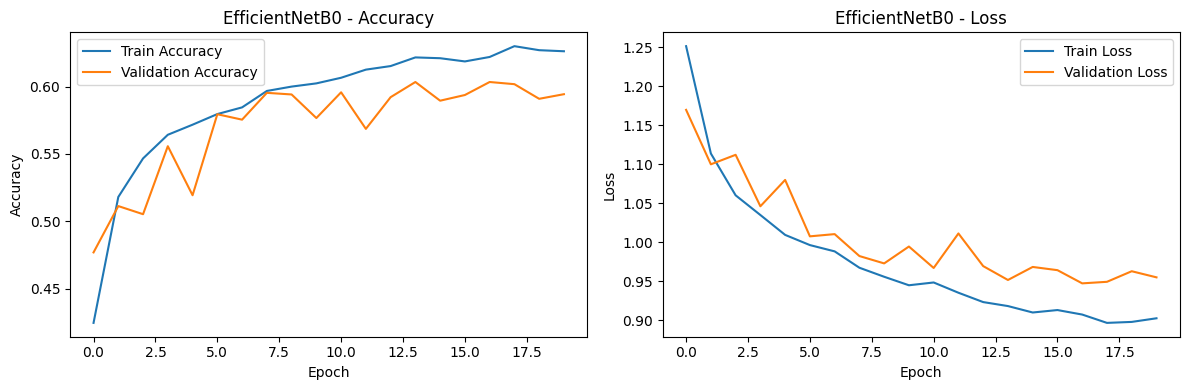%0A"
class="output-image" alt="Output" />

\[1m156/156\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m6s\[0m
39ms/step - accuracy: 0.6034 - loss: 0.9470 EfficientNetB0 - Validation
Loss: 0.9470 EfficientNetB0 - Validation Accuracy: 0.6034 \[1m4/4\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 42ms/step - accuracy:
0.6719 - loss: 0.8638 EfficientNetB0 - Test Loss: 0.8638
EfficientNetB0 - Test Accuracy: 0.6719 \[1m4/4\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m8s\[0m 52ms/step

<img
src="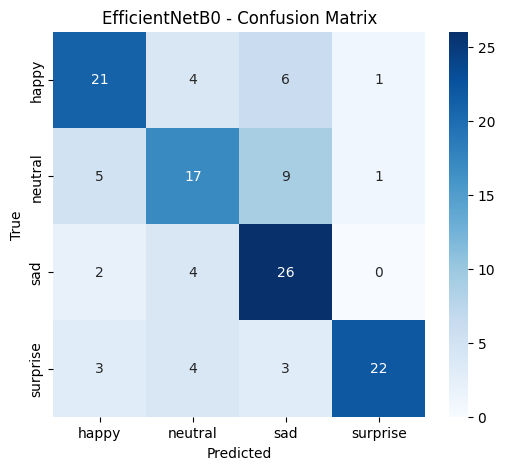%0A"
class="output-image" alt="Output" />

EfficientNetB0 Classification Report: precision recall f1-score support
happy 0.68 0.66 0.67 32 neutral 0.59 0.53 0.56 32 sad 0.59 0.81 0.68 32
surprise 0.92 0.69 0.79 32 accuracy 0.67 128 macro avg 0.69 0.67 0.67
128 weighted avg 0.69 0.67 0.67 128

 

**Interpretation:** This again confirms that the frozen transfer
learning backbones are not well suited for this dataset. It appears to
be better suited for task specific grayscale Custom CNN models.

 

### **Building a Complex Neural Network Architecture**

 

### **Model Building**

  

 

**Reasoning:** Tests if more depth and stronger regularization can
capture more subtle emotional patterns.

In \[ \]:

    complex_cnn = Sequential([ # Creates a sequential model
        Input(shape=(48, 48, 1)), # Defines the input shape
        Conv2D(32, (3, 3), activation="relu", padding="same"), # Applies 32 filters each being 3x3
        BatchNormalization(), # Normalizes the output of the convolution layer
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Conv2D(64, (3, 3), activation="relu", padding="same"), # Now applies 64 filters
        BatchNormalization(), # Normalizes the output of the convolution layer
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Conv2D(128, (3, 3), activation="relu", padding="same"), # Now applies 128 filters
        BatchNormalization(), # Normalizes the output of the convolution layer
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Conv2D(256, (3, 3), activation="relu", padding="same"), # Now applies 256 filters
        BatchNormalization(), # Normalizes the output of the convolution layer
        MaxPooling2D((2, 2)), # Reduces spatial size by half
        Flatten(), # Converts 3d feature maps to 1d vector
        Dense(256, activation="relu"), # Fully connected layer with 256 neurons
        Dropout(0.5), # Randomly turns off 50% of neurons during training
        Dense(128, activation="relu"), # Fully connected layer with 128 neurons
        Dropout(0.3), # Randomly turns off 30% of neurons during training
        Dense(4, activation="softmax") # Final classification layer
    ])

    complex_cnn.summary()

```
Model: "sequential_5"
```

```
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
```

```
 Total params: 1,013,252 (3.87 MB)
```

```
 Trainable params: 1,012,292 (3.86 MB)
```

```
 Non-trainable params: 960 (3.75 KB)
```

 

**Interpretation:** Builds directly on what the worked in the Second
Custom CNN model. It appears to be the strongest architecture wiht 4
convolution blocks and batch normalization throughout. It has a deeper
dense head and stronger dropout regularization.

 

### **Compiling and Training the Model**

 

**Reasoning:** Trains under the same grayscale pipeline and callback
regime as the earlier custom CNN models. Tests if deeper feature
extraction adds value.

In \[ \]:

    complex_cnn.compile( # Prepares the model for training
        optimizer=Adam(learning_rate=0.0005), # Uses the adaptive gradient method to set the learning rate
        loss="categorical_crossentropy", # Loss function for multi-class classification
        metrics=["accuracy"] # Tracks accuracy during training
    )

    history_complex = complex_cnn.fit( # Starts training and returns a history object
        train_gen_gray, # Training generator
        validation_data=val_gen_gray, # Evaluates the model after each epoch
        epochs=30, # Maximum number of training cycles
        callbacks=make_callbacks(), # Applies the callback function
        verbose=1 # Prints training progress per epoch
    )

Epoch 1/30 \[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m30s\[0m 47ms/step - accuracy: 0.3291 - loss: 1.4297 - val_accuracy:
0.3789 - val_loss: 1.2464 - learning_rate: 5.0000e-04 Epoch 2/30
\[1m473/473\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m
32ms/step - accuracy: 0.4116 - loss: 1.2437 - val_accuracy: 0.3146 -
val_loss: 1.4875 - learning_rate: 5.0000e-04 Epoch 3/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.4670 - loss: 1.1480 - val_accuracy: 0.4692 - val_loss: 1.1502 -
learning_rate: 5.0000e-04 Epoch 4/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.5204 - loss: 1.0710 - val_accuracy: 0.5236 - val_loss: 1.0651 -
learning_rate: 5.0000e-04 Epoch 5/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.5632 - loss: 0.9956 - val_accuracy: 0.5933 - val_loss: 0.9872 -
learning_rate: 5.0000e-04 Epoch 6/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 33ms/step - accuracy:
0.5867 - loss: 0.9407 - val_accuracy: 0.6482 - val_loss: 0.9061 -
learning_rate: 5.0000e-04 Epoch 7/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.6076 - loss: 0.9057 - val_accuracy: 0.6020 - val_loss: 0.9791 -
learning_rate: 5.0000e-04 Epoch 8/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.6283 - loss: 0.8750 - val_accuracy: 0.7006 - val_loss: 0.8347 -
learning_rate: 5.0000e-04 Epoch 9/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.6419 - loss: 0.8473 - val_accuracy: 0.6962 - val_loss: 0.8122 -
learning_rate: 5.0000e-04 Epoch 10/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.6574 - loss: 0.8248 - val_accuracy: 0.6974 - val_loss: 0.7810 -
learning_rate: 5.0000e-04 Epoch 11/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m22s\[0m 34ms/step - accuracy:
0.6680 - loss: 0.7982 - val_accuracy: 0.6470 - val_loss: 0.8525 -
learning_rate: 5.0000e-04 Epoch 12/30 \[1m471/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━\[0m\[37m━\[0m \[1m0s\[0m 29ms/step - accuracy:
0.6686 - loss: 0.7962 Epoch 12: ReduceLROnPlateau reducing learning rate
to 0.0002500000118743628. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.6703 - loss: 0.8013 - val_accuracy: 0.6633 - val_loss: 0.8326 -
learning_rate: 5.0000e-04 Epoch 13/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 34ms/step - accuracy:
0.6904 - loss: 0.7458 - val_accuracy: 0.7097 - val_loss: 0.7462 -
learning_rate: 2.5000e-04 Epoch 14/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7049 - loss: 0.7225 - val_accuracy: 0.7231 - val_loss: 0.7312 -
learning_rate: 2.5000e-04 Epoch 15/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.7040 - loss: 0.7186 - val_accuracy: 0.7217 - val_loss: 0.7583 -
learning_rate: 2.5000e-04 Epoch 16/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 31ms/step - accuracy:
0.7145 - loss: 0.7089 - val_accuracy: 0.7340 - val_loss: 0.7076 -
learning_rate: 2.5000e-04 Epoch 17/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.7178 - loss: 0.6945 - val_accuracy: 0.7296 - val_loss: 0.7551 -
learning_rate: 2.5000e-04 Epoch 18/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 28ms/step - accuracy:
0.7252 - loss: 0.6863 Epoch 18: ReduceLROnPlateau reducing learning rate
to 0.0001250000059371814. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.7228 - loss: 0.6920 - val_accuracy: 0.7376 - val_loss: 0.7074 -
learning_rate: 2.5000e-04 Epoch 19/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7376 - loss: 0.6588 - val_accuracy: 0.7412 - val_loss: 0.7044 -
learning_rate: 1.2500e-04 Epoch 20/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 34ms/step - accuracy:
0.7357 - loss: 0.6633 - val_accuracy: 0.7551 - val_loss: 0.6760 -
learning_rate: 1.2500e-04 Epoch 21/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7412 - loss: 0.6515 - val_accuracy: 0.7368 - val_loss: 0.7291 -
learning_rate: 1.2500e-04 Epoch 22/30 \[1m472/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━\[0m\[37m━\[0m \[1m0s\[0m 29ms/step - accuracy:
0.7438 - loss: 0.6418 Epoch 22: ReduceLROnPlateau reducing learning rate
to 6.25000029685907e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.7400 - loss: 0.6452 - val_accuracy: 0.7553 - val_loss: 0.6793 -
learning_rate: 1.2500e-04 Epoch 23/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 33ms/step - accuracy:
0.7476 - loss: 0.6298 - val_accuracy: 0.7513 - val_loss: 0.6879 -
learning_rate: 6.2500e-05 Epoch 24/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7505 - loss: 0.6261 - val_accuracy: 0.7567 - val_loss: 0.6506 -
learning_rate: 6.2500e-05 Epoch 25/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7514 - loss: 0.6194 - val_accuracy: 0.7537 - val_loss: 0.6712 -
learning_rate: 6.2500e-05 Epoch 26/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 29ms/step - accuracy:
0.7576 - loss: 0.6126 Epoch 26: ReduceLROnPlateau reducing learning rate
to 3.125000148429535e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7578 - loss: 0.6137 - val_accuracy: 0.7587 - val_loss: 0.6514 -
learning_rate: 6.2500e-05 Epoch 27/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7566 - loss: 0.6083 - val_accuracy: 0.7599 - val_loss: 0.6484 -
learning_rate: 3.1250e-05 Epoch 28/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m16s\[0m 33ms/step - accuracy:
0.7609 - loss: 0.6043 - val_accuracy: 0.7555 - val_loss: 0.6579 -
learning_rate: 3.1250e-05 Epoch 29/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 29ms/step - accuracy:
0.7620 - loss: 0.5970 Epoch 29: ReduceLROnPlateau reducing learning rate
to 1.5625000742147677e-05. \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 32ms/step - accuracy:
0.7611 - loss: 0.6004 - val_accuracy: 0.7583 - val_loss: 0.6521 -
learning_rate: 3.1250e-05 Epoch 30/30 \[1m473/473\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m15s\[0m 31ms/step - accuracy:
0.7615 - loss: 0.5963 - val_accuracy: 0.7625 - val_loss: 0.6453 -
learning_rate: 1.5625e-05 Restoring model weights from the end of the
best epoch: 30.

 

**Interpretation:** The model trained for 30 epochs. The model weights
were restored from epoch 27. This suggests epoch 28-30 did not perform
as well as epoch 27. It appears to be the strongest custom model
overall. It appears stable and has outperformed the Second Custom CNN
model on validation accuracy.

 

### **Evaluating the Model on Test Set**

 

**Reasoning:** Evaluates if the added complexity improves generalization
enough to justify deeper architecture.

In \[ \]:

    plot_history(history_complex, "Complex CNN") # Plots the training validation accuracy and loss

    val_loss_complex, val_acc_complex = evaluate_model( # Returns model validation data
        complex_cnn, val_gen_gray, "Complex CNN - Validation" # Accuracy and loss
    )
    test_loss_complex, test_acc_complex = evaluate_model( # Runs the model on unseen data
        complex_cnn, test_gen_gray, "Complex CNN - Test" # Accuracy and loss
    )

    classification_diagnostics(complex_cnn, test_gen_gray, "Complex CNN") # Predicts probabilities and converts class predictions, compares with true labels and builds the confusion matrix

<img
src="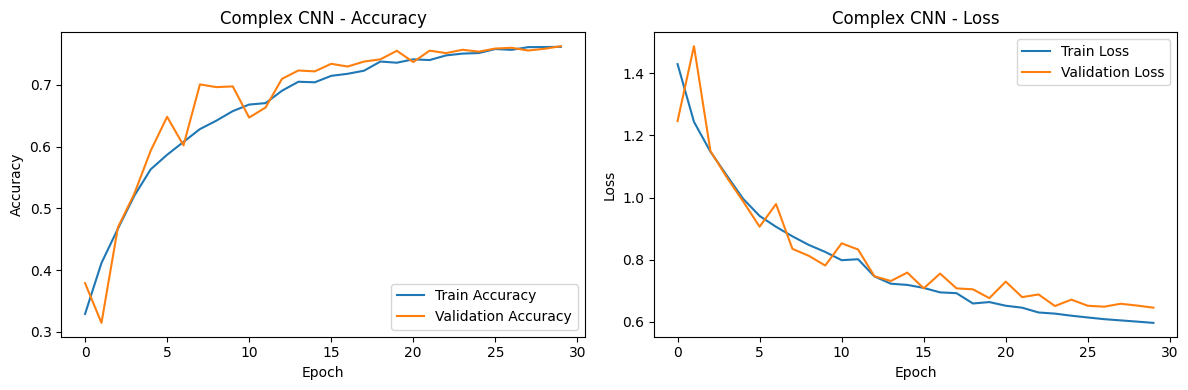%0A"
class="output-image" alt="Output" />

\[1m156/156\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m2s\[0m
15ms/step - accuracy: 0.7625 - loss: 0.6453 Complex CNN - Validation
Loss: 0.6453 Complex CNN - Validation Accuracy: 0.7625 \[1m4/4\[0m
\[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 18ms/step - accuracy:
0.8125 - loss: 0.5994 Complex CNN - Test Loss: 0.5994 Complex CNN - Test
Accuracy: 0.8125 \[1m4/4\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m
\[1m1s\[0m 16ms/step

<img
src="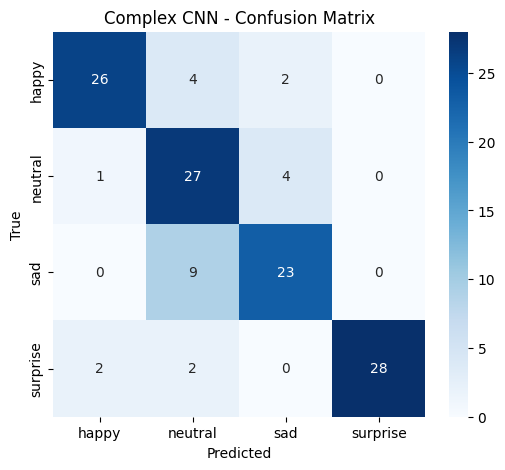%0A"
class="output-image" alt="Output" />

Complex CNN Classification Report: precision recall f1-score support
happy 0.90 0.81 0.85 32 neutral 0.64 0.84 0.73 32 sad 0.79 0.72 0.75 32
surprise 1.00 0.88 0.93 32 accuracy 0.81 128 macro avg 0.83 0.81 0.82
128 weighted avg 0.83 0.81 0.82 128

 

**Interpretation:** It appears the Complex CNN model outperformes the
other models with the highest validation accuracy and lowest validation
loss. This confirms the model as the best selection for the final model.

 

### **Plotting the Confusion Matrix for the chosen final model**

 

### **Final Model Section**

 

**Reasoning:** Gathers all the metrics into one table and ranks them
using validation performance. Gives clarity and transparency when
comparing multiple models.

In \[ \]:

    results = pd.DataFrame({ # Creates a pandas dataframe to store model performance results
        "Model": [ # Model list
            "Baseline CNN", # Name of first model
            "Second CNN", # Name of second model
            "Complex CNN", # Name of more advanced CNN model
            "VGG16", # Name of VGG16 transfer learning model
            "ResNet50V2", # Name of ResNet50V2 transfer learning model
            "EfficientNetB0" # Name of EfficientNetB0 transfer learning model
        ],
        "Validation Accuracy": [ # Validation list
            val_acc_baseline, # Validation for the Baseline CNN model
            val_acc_second, # Validation for the Second CNN model
            val_acc_complex, # Validation for the Complex CNN model
            val_acc_vgg, # Validation for the VGG16 model
            val_acc_resnet, # Validation for the ResNet50V2 model
            val_acc_eff # Validation for the EfficientNetB0 model
        ],
        "Validation Loss": [ # Validation loss list
            val_loss_baseline, # Validation loss for the Baseline CNN model
            val_loss_second, # Validation loss for the Second CNN model
            val_loss_complex, # Validation loss for the Complex CNN model
            val_loss_vgg, # Validation loss for the VGG16 model
            val_loss_resnet, # Validation loss for the ResNet50V2 model
            val_loss_eff # Validation loss for the EfficientNetB0 model
        ],
        "Test Accuracy": [ # Test accuracy list
            test_acc_baseline, # Test accuracy for the Baseline CNN model
            test_acc_second, # Test accuracy for the Second CNN model
            test_acc_complex, # Test accuracy for the Complex CNN model
            test_acc_vgg, # Test accuracy for the VGG16 model
            test_acc_resnet, # Test accuracy for the ResNet50V2 model
            test_acc_eff # Test accuracy for the EfficientNetB0 model
        ],
        "Test Loss": [ # Test loss list
            test_loss_baseline, # Test loss for the Baseline CNN model
            test_loss_second, # Test loss for the Second CNN model
            test_loss_complex, # Test loss for the Complex CNN model
            test_loss_vgg, # Test loss for the VGG16 model
            test_loss_resnet, # Test loss for the ResNet50V2 model
            test_loss_eff # Test loss for the EfficientNetB0 model
        ]
    })

    results_df = results.sort_values( # Sorts values for results
        by=["Validation Accuracy", "Validation Loss"], # Highest validation accuracy then lowest validation loss
        ascending=[False, True] # Descending for accuracy and ascending for loss
    ).reset_index(drop=True) # Resets index so ranking starts at 0

    results_df # Displays dataframe showing model comparisons

|     | Model          | Validation Accuracy | Validation Loss | Test Accuracy | Test Loss |
|-----|----------------|---------------------|-----------------|---------------|-----------|
| 0   | Complex CNN    | 0.762508            | 0.645333        | 0.812500      | 0.599437  |
| 1   | Second CNN     | 0.755877            | 0.626281        | 0.804688      | 0.495829  |
| 2   | ResNet50V2     | 0.701226            | 0.739264        | 0.703125      | 0.706121  |
| 3   | Baseline CNN   | 0.691782            | 0.744760        | 0.703125      | 0.631767  |
| 4   | EfficientNetB0 | 0.603376            | 0.947043        | 0.671875      | 0.863776  |
| 5   | VGG16          | 0.537071            | 1.074372        | 0.625000      | 0.976358  |





 

**Interpretation:** The comparison table confirms that the grayscale CNN
models outperform the transfer learning models. Showing the Complex CNN
model ranked first by validation performance. This confirms the Complex
CNN model as the best choice for the final model.

 

**Reasoning:** Extracts the winning model from the comparison table.

In \[ \]:

    best_name = results_df.loc[0, "Model"] # Accesses dataframe and selects value
    print("Selected best model based on validation performance:", best_name) # Prints message along with selected best model

Selected best model based on validation performance: Complex CNN

 

**Interpretation:** The selected best model based on validation
performance is the Complex CNN model.

 

**Reasoning:** Runs the final confusion matrix and classification
report. This ensures consistency in the reporting of the final model.

In \[ \]:

    if best_name == "Baseline CNN": # Checks of Baseline CNN model performed best
        classification_diagnostics(baseline_cnn, test_gen_gray, "Final Model - Baseline CNN") # Passes trained Baseline CNN model, Uses grayscale, labels plots and reports

    elif best_name == "Second CNN": # Checks if Second CNN model performed best
        classification_diagnostics(second_cnn, test_gen_gray, "Final Model - Second CNN") # Passes trained Second CNN model, Uses grayscale, labels plots and reports

    elif best_name == "Complex CNN": # Checks if Comlex CNN model performed best
        classification_diagnostics(complex_cnn, test_gen_gray, "Final Model - Complex CNN") # Passes trained Complex CNN model, Uses grayscale, labels plots and reports

    elif best_name == "VGG16": # Checks if VGG16 model performed best
        classification_diagnostics(vgg16_model, test_gen_vgg, "Final Model - VGG16") # Passes trained VGG16 model, Uses grayscale, labels plots and reports

    elif best_name == "ResNet50V2": # Checks if ResNet50V2 model performed best
        classification_diagnostics(resnet_model, test_gen_resnet, "Final Model - ResNet50V2") # Passes trained ResNet50V2 model, Uses grayscale, labels plots and reports

    elif best_name == "EfficientNetB0": # Checks if EfficientNetB0 model performed best
        classification_diagnostics(efficientnet_model, test_gen_eff, "Final Model - EfficientNetB0") # Passes trained EfficientNetB0 model, Uses grayscale, labels plots and reports

\[1m4/4\[0m \[32m━━━━━━━━━━━━━━━━━━━━\[0m\[37m\[0m \[1m0s\[0m 15ms/step

<img
src="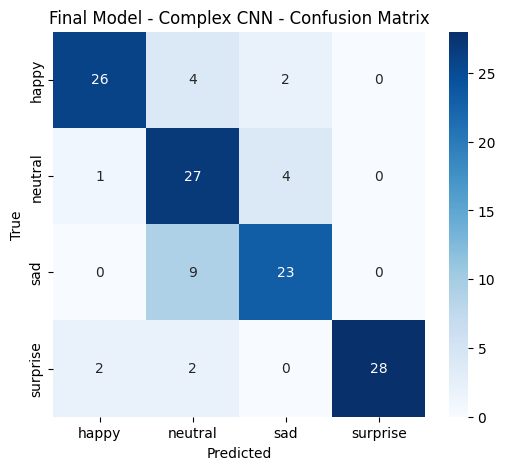%0A"
class="output-image" alt="Output" />

Final Model - Complex CNN Classification Report: precision recall
f1-score support happy 0.90 0.81 0.85 32 neutral 0.64 0.84 0.73 32 sad
0.79 0.72 0.75 32 surprise 1.00 0.88 0.93 32 accuracy 0.81 128 macro avg
0.83 0.81 0.82 128 weighted avg 0.83 0.81 0.82 128

 

**Interpretation:** The final confusion matrix is run for the selected
best model (Complex CNN). The report confirms that the Complex CNN model
achieves 0.81 percent accuracy with a strong macro and weighted F1.
Meaning that the model is accurate, balanced and succeeds on the easy as
well as difficult classes.

 

## **Insights & Recommendations**

  
  
The final model comarison showed that the custom grayscale CNN models
outperformed the frozen transfer learning models. The strongest model
was the Complex CNN, which achieved a validation accuracy of 0.7625 and
a test accuracy of 0.8125. This suggest that the dataset responds best
to task specific grayscal CNN architecture versus teh frozen pretrained
RGB backbones. The 48x48 grayscale images appeared to presearve enough
facial expression information for the custom CNN to learn meaningful
emotion patterns.  
  
The results showed increasing the CNN depth improved performance. The
Baseline CNN achieved a test accuracy of 0.7031, the second CNN improved
to 0.8047, and the Complex CNN reached 0.8125. This shows that adding
additional convolutional layers, batch normalization, and dropout helped
the model extract stronger expression features.  
  
At the class level, the model performed best on suprise and happy
classes. Suprise had the strongest final F1 score of 0.93. This is
likely because suprise features appear the most distinct. Happy also
performed well with a F1 score of 0.85. This is likely because smiles
create distinct and recognizable mouth and cheeck patterns.  
  
The most difficult classes were neutral and sad. They appeared to have
lower F1 scores. Meaning the model had more difficulty sperating out the
subtle of overlapping expressions.  
  
The recommended final model is the Complex CNN because it achieved the
highest validation and test accuracy. The grayscale CNN pipeline should
be kept as the primary approach. Future work should focus on fine-tuning
the transfer learning models instead of only using the frozen backbones.
Additions could include performing and error analysis on misclassified
images and adding a precision recall or ROC-style analysis.

Exported with [runcell](https://www.runcell.dev/tool/ipynb-to-html) —
convert notebooks to HTML or PDF anytime at runcell.dev.